**Multimodal Fusion for ICU Mortality Prediction using MIMIC‑III**

## Overview

This notebook builds and compares several models for in-hospital mortality prediction using MIMIC-III.

Four modalities are used:
1. Demographics (age, gender, admission type)
2. Aggregated vital signs (mean, min, max of HR, SBP, DBP, MAP, etc.)
3. Discrete clinical events (procedure and drug codes, as binary indicators)
4. 48-hour physiological time series (hourly vital sign sequences)

### Research questions
- RQ1: Does combining modalities beat the best single modality on its own?
- RQ2: Which fusion approach performs best, Early, Late, or Cross-Attention?
- RQ3: How much does each modality contribute (ablation)?
- RQ4: Do attention weights reveal how modality usage differs between patients who survived and those who didn't?

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

save_dir = '/content/drive/MyDrive/mimic_project'

patients_df = pd.read_csv(f'{save_dir}/patients_labels_demo.csv')
events_df = pd.read_csv(f'{save_dir}/discrete_events_final.csv')
agg = pd.read_csv(f'{save_dir}/vitals_agg.csv')
labs_pivot = pd.read_csv(f'{save_dir}/labs_summary.csv')

seq_data = np.load(f'{save_dir}/vitals_sequences.npz')
X_seq = seq_data['X_seq']
y_seq = seq_data['y_seq']
lengths = seq_data['lengths']
stay_ids_used = seq_data['stay_ids_used']

print("patients_df:", patients_df.shape)
print("events_df:", events_df.shape)
print("agg:", agg.shape)
print("labs_pivot:", labs_pivot.shape)
print("X_seq:", X_seq.shape, "| y_seq:", y_seq.shape, "| lengths:", lengths.shape)

Mounted at /content/drive
patients_df: (36515, 14)
events_df: (32534, 201)
agg: (35992, 22)
labs_pivot: (35756, 34)
X_seq: (35992, 48, 7) | y_seq: (35992,) | lengths: (35992,)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from scipy.stats import ttest_ind, chi2_contingency

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display
import pickle
import time

## 1. Data Alignment & Cohort Definition

In [ ]:
vitals_ids = set(stay_ids_used.tolist())
agg_ids = set(agg['icustay_id'].tolist())

stay_to_hadm = patients_df.set_index('icustay_id')['hadm_id'].to_dict()
events_hadm_ids = set(events_df['hadm_id'].tolist())
labs_hadm_ids = set(labs_pivot['hadm_id'].tolist())

common_ids = []
for sid in vitals_ids & agg_ids:
    hadm = stay_to_hadm.get(sid)
    if hadm in events_hadm_ids and hadm in labs_hadm_ids:
        common_ids.append(sid)

common_ids = sorted(common_ids)
print("patients with all 4 modalities:", len(common_ids))
print("original cohort size:", len(patients_df))

patients with all 4 modalities: 32043
original cohort size: 36515


In [ ]:
labels_lookup = patients_df.set_index('icustay_id')['mortality_label'].to_dict()
common_labels = np.array([labels_lookup[sid] for sid in common_ids])

train_ids, test_ids = train_test_split(
    common_ids, test_size=0.2, stratify=common_labels, random_state=42
)

# Split training set into actual training (80%) and calibration fit (20%)
train_ids_fit, train_ids_cal = train_test_split(
    train_ids,
    test_size=0.2,          # 20% of training data for Platt scaling
    stratify=[labels_lookup[s] for s in train_ids],
    random_state=42
)

print(f"Training (for model fit): {len(train_ids_fit)}")
print(f"Training (for calibration fit): {len(train_ids_cal)}")
print(f"Test (untouched): {len(test_ids)}")

print("train:", len(train_ids), "| test:", len(test_ids))
print("train mortality rate:", np.mean([labels_lookup[s] for s in train_ids]))
print("test mortality rate:", np.mean([labels_lookup[s] for s in test_ids]))

Training (for model fit): 20507
Training (for calibration fit): 5127
Test (untouched): 6409
train: 25634 | test: 6409
train mortality rate: 0.09877506436763674
test mortality rate: 0.09876735840224685


In [ ]:
# Check total stays vs unique patients in common_ids
common_patients = patients_df[patients_df['icustay_id'].isin(common_ids)]
total_stays = len(common_patients)
unique_patients = common_patients['subject_id'].nunique()

print(f"Total ICU Stays: {total_stays}")
print(f"Unique Patients: {unique_patients}")
print(f"Duplicates: {total_stays - unique_patients}")

Total ICU Stays: 32043
Unique Patients: 32043
Duplicates: 0


In [ ]:
excluded_ids = set(patients_df['icustay_id']) - set(common_ids)

included_df = patients_df[patients_df['icustay_id'].isin(common_ids)]
excluded_df = patients_df[patients_df['icustay_id'].isin(excluded_ids)]

print("Included (all 4 modalities):", len(included_df), "| Excluded:", len(excluded_df))
print()
print("Mortality rate — included:", included_df['mortality_label'].mean())
print("Mortality rate — excluded:", excluded_df['mortality_label'].mean())
print()
print("Mean age — included:", included_df['age'].mean())
print("Mean age — excluded:", excluded_df['age'].mean())
print()
print("Admission type — included:")
print(included_df['admission_type'].value_counts(normalize=True))
print()
print("Admission type — excluded:")
print(excluded_df['admission_type'].value_counts(normalize=True))

Included (all 4 modalities): 32043 | Excluded: 4472

Mortality rate — included: 0.09877352307836344
Mortality rate — excluded: 0.17553667262969588

Mean age — included: 62.42527229035983
Mean age — excluded: 61.78600178890876

Admission type — included:
admission_type
EMERGENCY    0.816715
ELECTIVE     0.166433
URGENT       0.016852
Name: proportion, dtype: float64

Admission type — excluded:
admission_type
EMERGENCY    0.726297
ELECTIVE     0.149374
URGENT       0.124329
Name: proportion, dtype: float64


In [ ]:
from scipy.stats import ttest_ind, chisquare, chi2_contingency

# T-test for Age difference
t_stat, p_val_age = ttest_ind(included_df['age'].dropna(), excluded_df['age'].dropna())

# Chi-Square for Mortality difference
contingency_mort = pd.crosstab(patients_df['icustay_id'].isin(common_ids), patients_df['mortality_label'])
chi2_mort, p_val_mort, _, _ = chi2_contingency(contingency_mort)

print(f"Age Difference P-Value: {p_val_age:.4f}")
print(f"Mortality Difference P-Value: {p_val_mort:.4e}")

Age Difference P-Value: 0.0175
Mortality Difference P-Value: 6.8234e-54


Complete-case cohort: 32,043 ICU stays (87.8% of original)

## 2. Unimodal Baselines (Logistic Regression & LSTM)

In [ ]:
model_df = patients_df.merge(agg, on='icustay_id', how='inner')
model_df = model_df.set_index('icustay_id')

feature_cols_vitals = ['age','hr_mean','hr_min','hr_max','sbp_mean','sbp_min','sbp_max',
                 'dbp_mean','dbp_min','dbp_max','resp_mean','resp_min','resp_max',
                 'temp_mean','temp_min','temp_max','spo2_mean','spo2_min','spo2_max',
                 'map_mean','map_min','map_max']

X_train_v = model_df.loc[train_ids_fit, feature_cols_vitals]
X_test_v = model_df.loc[test_ids, feature_cols_vitals]
y_train_v = model_df.loc[train_ids_fit, 'mortality_label']
y_test_v = model_df.loc[test_ids, 'mortality_label']

imputer = SimpleImputer(strategy='mean')
X_train_v_imp = imputer.fit_transform(X_train_v)
X_test_v_imp = imputer.transform(X_test_v)

scaler = StandardScaler()
X_train_v_s = scaler.fit_transform(X_train_v_imp)
X_test_v_s = scaler.transform(X_test_v_imp)

logreg_v = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg_v.fit(X_train_v_s, y_train_v)
probs_v = logreg_v.predict_proba(X_test_v_s)[:, 1]

print("Fair baseline — LogReg (vitals+demo), n =", len(X_train_v)+len(X_test_v))
print("AUROC:", roc_auc_score(y_test_v, probs_v))
print("AUPRC:", average_precision_score(y_test_v, probs_v))

Fair baseline — LogReg (vitals+demo), n = 26916
AUROC: 0.7901771452827628
AUPRC: 0.35067367777451025


### Unimodal baseline: discrete events (LogReg)

In [ ]:
model_df_ev = patients_df.merge(events_df, on='hadm_id', how='inner')
model_df_ev = model_df_ev.set_index('icustay_id')

feature_cols_ev = [c for c in events_df.columns if c != 'hadm_id']

# Remove leakage codes (family meetings happen after deterioration, not before)
leakage_codes = ['proc_Family met with Social Worker', 'proc_Family updated by MD']
feature_cols_ev = [c for c in feature_cols_ev if c not in leakage_codes]

X_train_e = model_df_ev.loc[train_ids_fit, feature_cols_ev]
X_test_e = model_df_ev.loc[test_ids, feature_cols_ev]
y_train_e = model_df_ev.loc[train_ids_fit, 'mortality_label']
y_test_e = model_df_ev.loc[test_ids, 'mortality_label']

logreg_e = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg_e.fit(X_train_e, y_train_e)
probs_e = logreg_e.predict_proba(X_test_e)[:, 1]

print("Fair baseline — LogReg (discrete events), n_train =", len(X_train_e))
print("AUROC:", roc_auc_score(y_test_e, probs_e))
print("AUPRC:", average_precision_score(y_test_e, probs_e))

Fair baseline — LogReg (discrete events), n_train = 20507
AUROC: 0.847927142000674
AUPRC: 0.39586000486233797


In [ ]:
coefs_fair = pd.Series(logreg_e.coef_[0], index=feature_cols_ev).sort_values(ascending=False)
print("Top 15 positive coefficients (fair, shared-subset discrete events model):")
print(coefs_fair.head(15))

Top 15 positive coefficients (fair, shared-subset discrete events model):
proc_Intraventricular Drain Inserted    1.675446
proc_Drain Removed                      1.532764
proc_Triple Introducer                  1.411063
proc_Paracentesis                       1.278624
proc_Invasive Ventilation               1.255522
proc_Radiation Therapy                  1.117099
proc_Indwelling Port (PortaCath)        1.017189
drug_Soln.                              0.992265
proc_Nuclear Medicine                   0.976427
drug_Morphine Sulfate                   0.951260
proc_Intraosseous Device                0.906895
drug_D5W                                0.894576
proc_PEG Insertion                      0.778669
proc_Trauma line                        0.742781
proc_RIC                                0.734687
dtype: float64


In [ ]:
model_df_labs = patients_df.merge(labs_pivot, on='hadm_id', how='inner')
model_df_labs = model_df_labs.set_index('icustay_id')

feature_cols_labs = [c for c in labs_pivot.columns if c != 'hadm_id']

X_train_labs = model_df_labs.loc[train_ids_fit, feature_cols_labs]
X_test_labs = model_df_labs.loc[test_ids, feature_cols_labs]
y_train_labs = model_df_labs.loc[train_ids_fit, 'mortality_label']
y_test_labs = model_df_labs.loc[test_ids, 'mortality_label']

labs_imputer = SimpleImputer(strategy='median')
X_train_labs_imp = labs_imputer.fit_transform(X_train_labs)
X_test_labs_imp = labs_imputer.transform(X_test_labs)

labs_scaler = StandardScaler()
X_train_labs_s = labs_scaler.fit_transform(X_train_labs_imp)
X_test_labs_s = labs_scaler.transform(X_test_labs_imp)

logreg_labs_fair = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg_labs_fair.fit(X_train_labs_s, y_train_labs)
probs_labs_fair = logreg_labs_fair.predict_proba(X_test_labs_s)[:, 1]

print("Fair baseline — LogReg (labs), n_train =", len(X_train_labs))
print("AUROC:", roc_auc_score(y_test_labs, probs_labs_fair))
print("AUPRC:", average_precision_score(y_test_labs, probs_labs_fair))

Fair baseline — LogReg (labs), n_train = 20507
AUROC: 0.809369434124098
AUPRC: 0.4124008125861367


### Unimodal Baseline: Vitals Time Series (LSTM)

In [ ]:
stay_id_to_idx = {sid: i for i, sid in enumerate(stay_ids_used)}

train_idx = [stay_id_to_idx[s] for s in train_ids_fit if s in stay_id_to_idx]
cal_idx   = [stay_id_to_idx[s] for s in train_ids_cal if s in stay_id_to_idx]
test_idx  = [stay_id_to_idx[s] for s in test_ids if s in stay_id_to_idx]

X_train_seq = X_seq[train_idx]
X_cal_seq   = X_seq[cal_idx]
X_test_seq  = X_seq[test_idx]

y_train_seq = y_seq[train_idx]
y_cal_seq   = y_seq[cal_idx]
y_test_seq  = y_seq[test_idx]

len_train_seq = lengths[train_idx]
len_cal_seq   = lengths[cal_idx]
len_test_seq  = lengths[test_idx]

train_mean = X_train_seq.reshape(-1, X_train_seq.shape[-1]).mean(axis=0)
train_std  = X_train_seq.reshape(-1, X_train_seq.shape[-1]).std(axis=0) + 1e-6

# Scale train, cal, and test sets
X_train_seq = (X_train_seq - train_mean) / train_std
X_cal_seq   = (X_cal_seq - train_mean) / train_std
X_test_seq  = (X_test_seq - train_mean) / train_std

class ICUDataset(Dataset):
    def __init__(self, X, y, lengths):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.lengths = torch.tensor(lengths, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.lengths[idx]

# Create DataLoaders
train_loader = DataLoader(ICUDataset(X_train_seq, y_train_seq, len_train_seq), batch_size=64, shuffle=True)
cal_loader   = DataLoader(ICUDataset(X_cal_seq, y_cal_seq, len_cal_seq), batch_size=64, shuffle=False)
test_loader  = DataLoader(ICUDataset(X_test_seq, y_test_seq, len_test_seq), batch_size=64, shuffle=False)

print(f"train_fit: {len(train_idx)} | cal: {len(cal_idx)} | test: {len(test_idx)}")

train_fit: 20507 | cal: 5127 | test: 6409


### Training the LSTM on the Subset

In [ ]:
class VitalsLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2 if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        lengths = lengths.to(x.device) 
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        lstm_out, _ = self.lstm(packed)
        unpacked, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        mask = (x != 0).any(dim=-1).float()
        pooled = (unpacked * mask.unsqueeze(-1)).sum(dim=1) / lengths.float().unsqueeze(1)
        return self.fc(pooled).squeeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
model_lstm = VitalsLSTM().to(device)

pos_weight = torch.tensor([(len(y_train_seq) - y_train_seq.sum()) / y_train_seq.sum()]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

for epoch in range(20):
    model_lstm.train()
    total_loss = 0
    for xb, yb, lb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model_lstm(xb, lb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"epoch {epoch+1}/10  loss: {total_loss/len(train_loader):.4f}")

model_lstm.eval()
probs_lstm, labels_lstm = [], []
with torch.no_grad():
    for xb, yb, lb in test_loader:
        p = torch.sigmoid(model_lstm(xb.to(device), lb)).cpu().numpy()
        probs_lstm.extend(p)
        labels_lstm.extend(yb.numpy())

print("Fair baseline — LSTM (vitals)")
print("AUROC:", roc_auc_score(labels_lstm, probs_lstm))
print("AUPRC:", average_precision_score(labels_lstm, probs_lstm))

epoch 1/10  loss: 1.1700
epoch 2/10  loss: 1.1265
epoch 3/10  loss: 1.0969
epoch 4/10  loss: 1.0774
epoch 5/10  loss: 1.0642
epoch 6/10  loss: 1.0451
epoch 7/10  loss: 1.0324
epoch 8/10  loss: 1.0220
epoch 9/10  loss: 1.0113
epoch 10/10  loss: 1.0061
epoch 11/10  loss: 0.9929
epoch 12/10  loss: 0.9823
epoch 13/10  loss: 0.9778
epoch 14/10  loss: 0.9631
epoch 15/10  loss: 0.9586
epoch 16/10  loss: 0.9517
epoch 17/10  loss: 0.9409
epoch 18/10  loss: 0.9283
epoch 19/10  loss: 0.9253
epoch 20/10  loss: 0.9211
Fair baseline — LSTM (vitals)
AUROC: 0.8281820946729506
AUPRC: 0.4487351398103873


## 3. Multimodal Fusion Architectures

In [ ]:
demo_cols_raw = ['age', 'gender', 'admission_type']
demo_df = patients_df.set_index('icustay_id')[demo_cols_raw].copy()

# gender as a single binary column (not one-hot)
demo_df['gender_male'] = (demo_df['gender'] == 'M').astype(float)
demo_df = demo_df.drop(columns=['gender'])

# admission_type one-hot
demo_df = pd.get_dummies(demo_df, columns=['admission_type'], drop_first=False)

demo_train = demo_df.loc[train_ids_fit].astype(float)
demo_test = demo_df.loc[test_ids].astype(float)

demo_scaler = StandardScaler()
demo_train_s = demo_scaler.fit_transform(demo_train)
demo_test_s = demo_scaler.transform(demo_test)

print("demo train shape:", demo_train_s.shape)
print("demo columns:", demo_df.columns.tolist())

demo train shape: (20507, 5)
demo columns: ['age', 'gender_male', 'admission_type_ELECTIVE', 'admission_type_EMERGENCY', 'admission_type_URGENT']


In [ ]:
y_train_fit = patients_df.set_index('icustay_id').loc[train_ids_fit, 'mortality_label']
y_test = patients_df.set_index('icustay_id').loc[test_ids, 'mortality_label']

logreg_demo = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg_demo.fit(demo_train_s, y_train_fit)
probs_demo = logreg_demo.predict_proba(demo_test_s)[:, 1]

print("Demographics Only Baseline (N = 20,507):")
print("AUROC:", roc_auc_score(y_test, probs_demo))
print("AUPRC:", average_precision_score(y_test, probs_demo))

Demographics Only Baseline (N = 20,507):
AUROC: 0.6615605567298142
AUPRC: 0.16600520769839805


In [ ]:
# Vitals Sequences (from train_ids_fit, N = 20,507)
vitals_seq_train = torch.tensor(X_train_seq, dtype=torch.float32)
vitals_len_train = torch.tensor(len_train_seq, dtype=torch.long)
vitals_seq_test  = torch.tensor(X_test_seq, dtype=torch.float32)
vitals_len_test  = torch.tensor(len_test_seq, dtype=torch.long)

# Demographics (from train_ids_fit, N = 20,507)
demo_train_t = torch.tensor(demo_train_s, dtype=torch.float32)
demo_test_t  = torch.tensor(demo_test_s, dtype=torch.float32)

# Discrete Events
events_train_t = torch.tensor(X_train_e.values, dtype=torch.float32)
events_test_t  = torch.tensor(X_test_e.values, dtype=torch.float32)

# Labs 
labs_train_t = torch.tensor(X_train_labs_s, dtype=torch.float32)
labs_test_t  = torch.tensor(X_test_labs_s, dtype=torch.float32)

# Targets
labels_train_t = torch.tensor(y_train_seq, dtype=torch.float32)
labels_test_t  = torch.tensor(y_test_seq, dtype=torch.float32)

print("Vitals:", vitals_seq_train.shape)
print("Demo:  ", demo_train_t.shape)
print("Events:", events_train_t.shape)
print("Labs:  ", labs_train_t.shape)
print("Labels:", labels_train_t.shape)

Vitals: torch.Size([20507, 48, 7])
Demo:   torch.Size([20507, 5])
Events: torch.Size([20507, 198])
Labs:   torch.Size([20507, 33])
Labels: torch.Size([20507])


In [ ]:
class FusionDataset(Dataset):
    def __init__(self, vitals, lengths, demo, events, labs, labels):
        self.vitals = vitals
        self.lengths = lengths
        self.demo = demo
        self.events = events
        self.labs = labs
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (self.vitals[idx], self.lengths[idx], self.demo[idx],
                self.events[idx], self.labs[idx], self.labels[idx])

fusion_train_loader = DataLoader(
    FusionDataset(vitals_seq_train, vitals_len_train, demo_train_t,
                  events_train_t, labs_train_t, labels_train_t),
    batch_size=64, shuffle=True
)

fusion_test_loader = DataLoader(
    FusionDataset(vitals_seq_test, vitals_len_test, demo_test_t,
                  events_test_t, labs_test_t, labels_test_t),
    batch_size=64, shuffle=False
)

In [ ]:
class VitalsEncoder(nn.Module):
    def __init__(self, input_size=6, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        return h_n[-1] 

class DemoEncoder(nn.Module):
    def __init__(self, input_size, hidden_size=16):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_size, hidden_size), nn.ReLU())
    def forward(self, x):
        return self.net(x)

class EventsEncoder(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_size, hidden_size), nn.ReLU())
    def forward(self, x):
        return self.net(x)

class LabsEncoder(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_size, hidden_size), nn.ReLU())
    def forward(self, x):
        return self.net(x)

In [ ]:
class EarlyFusionModel(nn.Module):
    def __init__(self, vitals_input=7, demo_input=4, events_input=200, labs_input=33):
        super().__init__()
        self.vitals_enc = VitalsEncoder(input_size=vitals_input)
        self.demo_enc = DemoEncoder(input_size=demo_input)
        self.events_enc = EventsEncoder(input_size=events_input)
        self.labs_enc = LabsEncoder(input_size=labs_input)
        combined_dim = 32 + 16 + 32 + 32
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, vitals_x, vitals_len, demo_x, events_x, labs_x):
        v = self.vitals_enc(vitals_x, vitals_len)
        d = self.demo_enc(demo_x)
        e = self.events_enc(events_x)
        l = self.labs_enc(labs_x)
        combined = torch.cat([v, d, e, l], dim=1)
        return self.classifier(combined).squeeze(1)

model_early = EarlyFusionModel(
    vitals_input=X_train_seq.shape[-1],
    demo_input=demo_train_t.shape[1],
    events_input=events_train_t.shape[1],
    labs_input=labs_train_t.shape[1]
).to(device)


### 3.1 Early Fusion (concatenation + MLP)

In [ ]:
# Early Fusion

def apply_modality_masking(vb, db, eb, lab_b, mask_prob=0.15):
    batch_size = vb.size(0)
    device = vb.device
    mask_v = (torch.rand(batch_size, 1, 1, device=device) > mask_prob).float()
    mask_d = (torch.rand(batch_size, 1, device=device) > mask_prob).float()
    mask_e = (torch.rand(batch_size, 1, device=device) > mask_prob).float()
    mask_l = (torch.rand(batch_size, 1, device=device) > mask_prob).float()
    return vb * mask_v, db * mask_d, eb * mask_e, lab_b * mask_l

torch.manual_seed(42)
np.random.seed(42)
model_early = EarlyFusionModel(
    vitals_input=vitals_seq_train.shape[-1],
    demo_input=demo_train_t.shape[1],
    events_input=events_train_t.shape[1],
    labs_input=labs_train_t.shape[1]
).to(device)

pos_weight = torch.tensor([(len(labels_train_t) - labels_train_t.sum()) / labels_train_t.sum()]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_early.parameters(), lr=1e-3)

EPOCHS = 30
for epoch in range(EPOCHS):
    model_early.train()
    running_loss = 0.0
    for vb, lb, db, eb, lab_b, yb in fusion_train_loader:
        vb, db, eb, lab_b, yb = vb.to(device), db.to(device), eb.to(device), lab_b.to(device), yb.to(device)
        vb, db, eb, lab_b = apply_modality_masking(vb, db, eb, lab_b, mask_prob=0.15)
        optimizer.zero_grad()
        logits = model_early(vb, lb, db, eb, lab_b)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS}  loss: {running_loss/len(fusion_train_loader):.4f}")

model_early.eval()
probs_te, labels_te = [], []
with torch.no_grad():
    for vb, lb, db, eb, lab_b, yb in fusion_test_loader:
        vb, db, eb, lab_b = vb.to(device), db.to(device), eb.to(device), lab_b.to(device)
        logits = model_early(vb, lb, db, eb, lab_b)
        probs_te.extend(torch.sigmoid(logits).cpu().numpy())
        labels_te.extend(yb.numpy())

print("\n Early Fusion (30 epochs + masking)")
print("AUROC:", roc_auc_score(labels_te, probs_te))
print("AUPRC:", average_precision_score(labels_te, probs_te))

Epoch 05/30  loss: 0.7160
Epoch 10/30  loss: 0.6359
Epoch 15/30  loss: 0.5625
Epoch 20/30  loss: 0.5056
Epoch 25/30  loss: 0.4593
Epoch 30/30  loss: 0.4018

 Early Fusion (30 epochs + masking)
AUROC: 0.877781570413937
AUPRC: 0.5635545814409747


In [ ]:
p_vitals = np.array(probs_v).flatten()
p_events = np.array(probs_e).flatten()
p_lstm   = np.array(probs_lstm).flatten()
p_labs   = np.array(probs_labs_fair).flatten()

probs_late_fusion = np.mean([p_vitals, p_events, p_lstm, p_labs], axis=0)

y_test_true = y_test_v.values 

print("Late Fusion (Simple Average of 4 Modalities)")
print("AUROC:", roc_auc_score(y_test_true, probs_late_fusion))
print("AUPRC:", average_precision_score(y_test_true, probs_late_fusion))


Late Fusion (Simple Average of 4 Modalities)
AUROC: 0.9012985585065183
AUPRC: 0.5666581022034106


In [ ]:
lengths_arr = np.array(len_test_seq)
p_lstm_arr = np.array(probs_lstm).flatten()
y_arr = np.array(y_test_true)

short_mask = lengths_arr <= 12
long_mask = lengths_arr > 12

print(f"Short stays (<=12h): n = {short_mask.sum()}")
print("AUROC:", roc_auc_score(y_arr[short_mask], p_lstm_arr[short_mask]))
print("AUPRC:", average_precision_score(y_arr[short_mask], p_lstm_arr[short_mask]))

print(f"\nLonger stays (>12h): n = {long_mask.sum()}")
print("AUROC:", roc_auc_score(y_arr[long_mask], p_lstm_arr[long_mask]))
print("AUPRC:", average_precision_score(y_arr[long_mask], p_lstm_arr[long_mask]))

Short stays (<=12h): n = 96
AUROC: 0.9420289855072465
AUPRC: 0.8852755528724133

Longer stays (>12h): n = 6313
AUROC: 0.8231056065129905
AUPRC: 0.42285301982436363


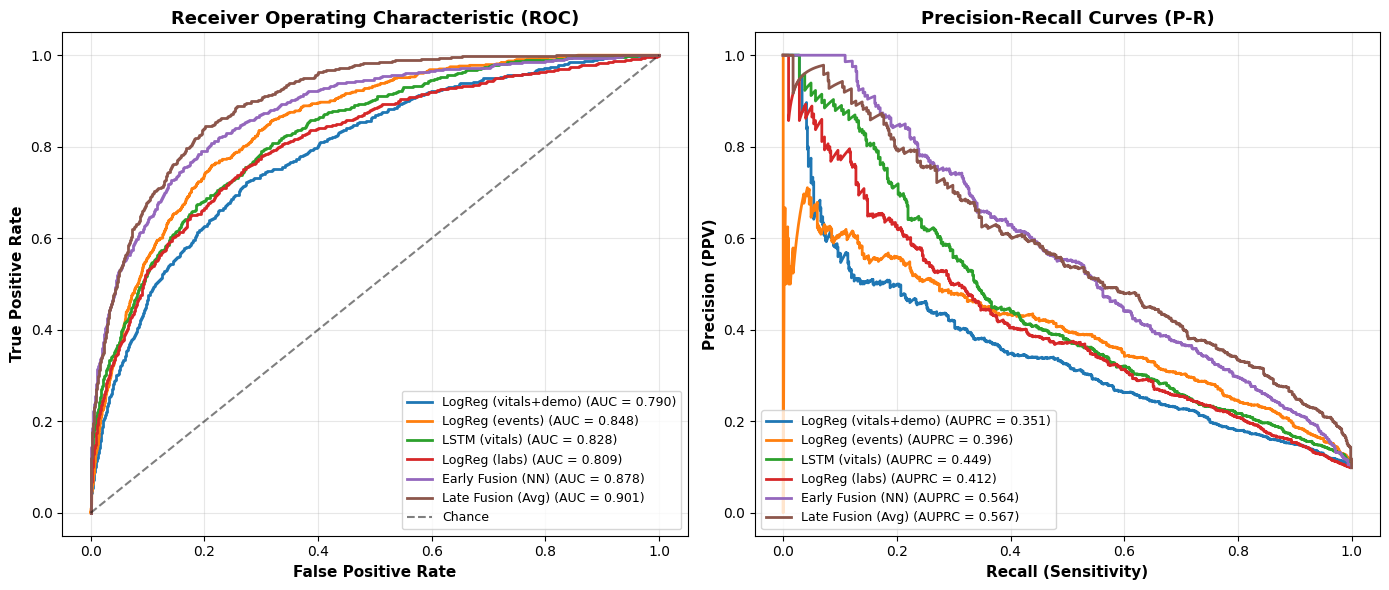

In [ ]:
p_vitals = np.array(probs_v).flatten()
p_events = np.array(probs_e).flatten()
p_lstm   = np.array(probs_lstm).flatten()
p_labs   = np.array(probs_labs_fair).flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

models_dict = {
    'LogReg (vitals+demo)': (p_vitals, y_test_v.values),
    'LogReg (events)':      (p_events, y_test_e.values),
    'LSTM (vitals)':        (p_lstm, y_test_true),
    'LogReg (labs)':        (p_labs, y_test_labs.values),
    'Early Fusion (NN)':    (probs_te, labels_te),
    'Late Fusion (Avg)':    (probs_late_fusion, y_test_true)
}

# ROC Curves
for name, (preds, true_y) in models_dict.items():
    fpr, tpr, _ = roc_curve(true_y, preds)
    auc_val = roc_auc_score(true_y, preds)
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", linewidth=2)

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Chance')
ax1.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax1.set_title('Receiver Operating Characteristic (ROC)', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Precision-Recall Curves
for name, (preds, true_y) in models_dict.items():
    precision, recall, _ = precision_recall_curve(true_y, preds)
    auprc_val = average_precision_score(true_y, preds)
    ax2.plot(recall, precision, label=f"{name} (AUPRC = {auprc_val:.3f})", linewidth=2)

ax2.set_xlabel('Recall (Sensitivity)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Precision (PPV)', fontsize=11, fontweight='bold')
ax2.set_title('Precision-Recall Curves (P-R)', fontsize=13, fontweight='bold')
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

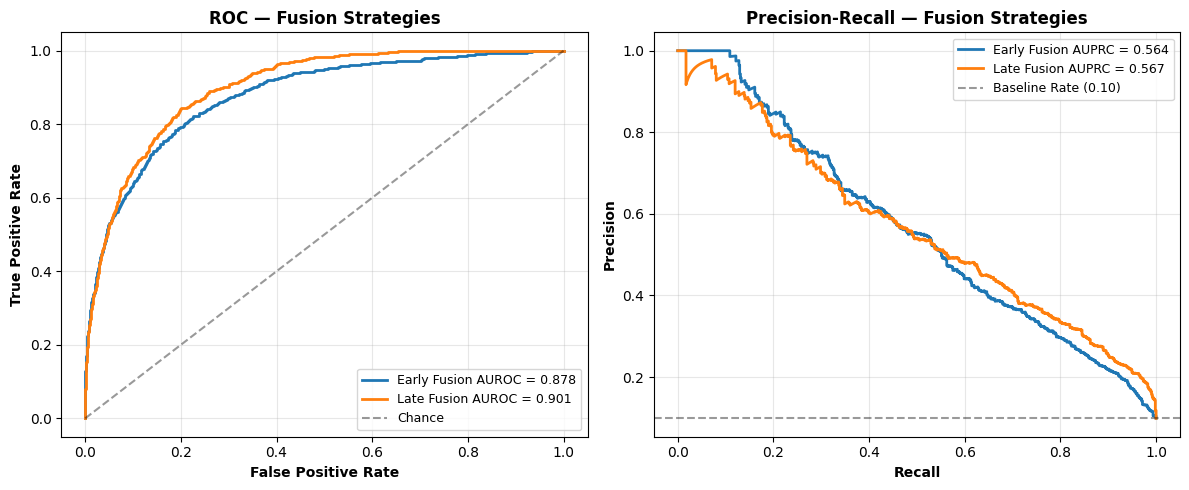

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curves
fpr_e, tpr_e, _ = roc_curve(labels_te, probs_te)
axes[0].plot(fpr_e, tpr_e, label=f'Early Fusion AUROC = {roc_auc_score(labels_te, probs_te):.3f}', linewidth=2)

fpr_l, tpr_l, _ = roc_curve(y_test_true, probs_late_fusion)
axes[0].plot(fpr_l, tpr_l, label=f'Late Fusion AUROC = {roc_auc_score(y_test_true, probs_late_fusion):.3f}', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('ROC — Fusion Strategies', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curves
p_e, r_e, _ = precision_recall_curve(labels_te, probs_te)
axes[1].plot(r_e, p_e, label=f'Early Fusion AUPRC = {average_precision_score(labels_te, probs_te):.3f}', linewidth=2)

p_l, r_l, _ = precision_recall_curve(y_test_true, probs_late_fusion)
axes[1].plot(r_l, p_l, label=f'Late Fusion AUPRC = {average_precision_score(y_test_true, probs_late_fusion):.3f}', linewidth=2)

axes[1].axhline(np.mean(y_test_true), color='k', linestyle='--', alpha=0.4, label=f'Baseline Rate ({np.mean(y_test_true):.2f})')
axes[1].set_xlabel('Recall', fontweight='bold')
axes[1].set_ylabel('Precision', fontweight='bold')
axes[1].set_title('Precision-Recall — Fusion Strategies', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

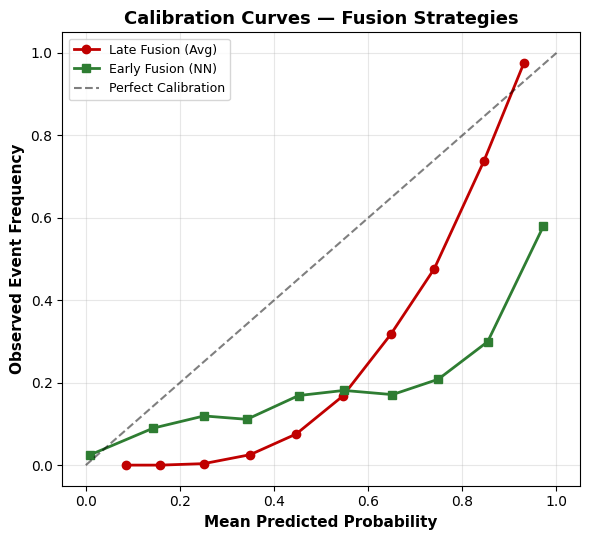

In [ ]:
# calibration curves
frac_pos_late, mean_pred_late = calibration_curve(y_test_true, probs_late_fusion, n_bins=10)
frac_pos_early, mean_pred_early = calibration_curve(labels_te, probs_te, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 5.5))

# Plot Late & Early Fusion calibration
ax.plot(mean_pred_late, frac_pos_late, marker='o', linewidth=2, label='Late Fusion (Avg)', color='#C00000')
ax.plot(mean_pred_early, frac_pos_early, marker='s', linewidth=2, label='Early Fusion (NN)', color='#2E7D32')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect Calibration')

ax.set_xlabel('Mean Predicted Probability', fontweight='bold', fontsize=11)
ax.set_ylabel('Observed Event Frequency', fontweight='bold', fontsize=11)
ax.set_title('Calibration Curves — Fusion Strategies', fontweight='bold', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fusion_calibration.png', dpi=300, bbox_inches='tight')
plt.show()

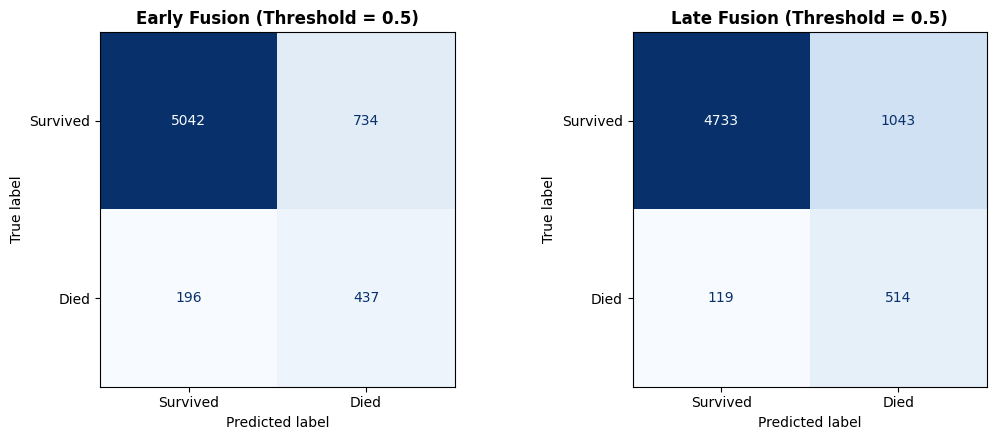

In [ ]:
# Convert probabilities to binary predictions using 0.5 threshold
threshold = 0.5
preds_early_bin = (np.array(probs_te) >= threshold).astype(int)
preds_late_bin  = (np.array(probs_late_fusion) >= threshold).astype(int)

cm_early = confusion_matrix(labels_te, preds_early_bin)
cm_late  = confusion_matrix(y_test_true, preds_late_bin)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Plot early-fusion confusion matrix
disp_early = ConfusionMatrixDisplay(confusion_matrix=cm_early, display_labels=['Survived', 'Died'])
disp_early.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Early Fusion (Threshold = 0.5)', fontweight='bold')

# Plot Late Fusion Confusion Matrix
disp_late = ConfusionMatrixDisplay(confusion_matrix=cm_late, display_labels=['Survived', 'Died'])
disp_late.plot(ax=axes[1], cmap='Blues', values_format='d', colorbar=False)
axes[1].set_title('Late Fusion (Threshold = 0.5)', fontweight='bold')

plt.tight_layout()
plt.savefig('chart_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

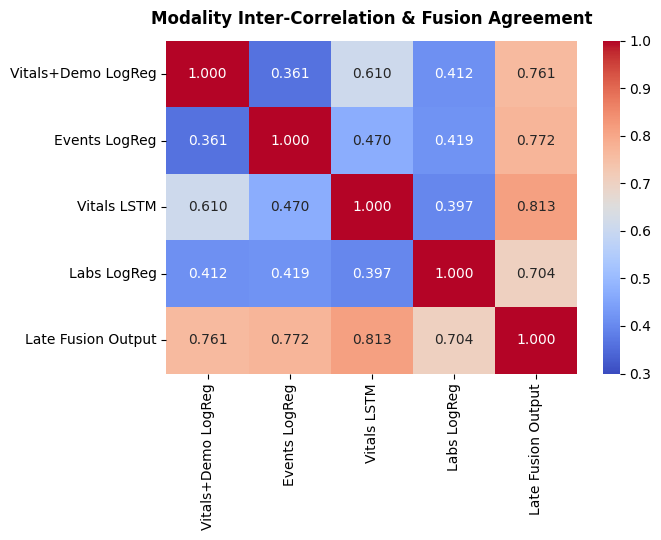

In [ ]:
modality_df = pd.DataFrame({
    'Vitals+Demo LogReg': p_vitals,
    'Events LogReg': p_events,
    'Vitals LSTM': p_lstm,
    'Labs LogReg': p_labs,
    'Late Fusion Output': probs_late_fusion
})

# correlation matrix
corr = modality_df.corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=0.3, vmax=1.0, cbar=True)
plt.title('Modality Inter-Correlation & Fusion Agreement', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('modality_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.2 Cross-Attention Fusion (self-attention over modality tokens)

In [ ]:
def apply_modality_masking(vb, db, eb, lab_b, mask_prob=0.15):
    
    batch_size = vb.size(0)
    device = vb.device

    # Create random masks
    mask_v = (torch.rand(batch_size, 1, 1, device=device) > mask_prob).float()
    mask_d = (torch.rand(batch_size, 1, device=device) > mask_prob).float()
    mask_e = (torch.rand(batch_size, 1, device=device) > mask_prob).float()
    mask_l = (torch.rand(batch_size, 1, device=device) > mask_prob).float()

    return vb * mask_v, db * mask_d, eb * mask_e, lab_b * mask_l

In [ ]:
class CrossAttentionFusionModel(nn.Module):
    def __init__(self, vitals_input, demo_input, events_input, labs_input, embed_dim=32, n_heads=4):
        super().__init__()

        self.vitals_enc = VitalsEncoder(input_size=vitals_input)
        self.demo_enc   = DemoEncoder(input_size=demo_input)     # outputs 16 dim
        self.events_enc = EventsEncoder(input_size=events_input) # outputs 32 dim
        self.labs_enc   = LabsEncoder(input_size=labs_input)     # outputs 32 dim

        self.proj_v = nn.Linear(32, embed_dim)
        self.proj_d = nn.Linear(16, embed_dim)
        self.proj_e = nn.Linear(32, embed_dim)
        self.proj_l = nn.Linear(32, embed_dim)

        # Multi-Head Attention
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=n_heads, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 4, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1)
        )

    def forward(self, vitals_x, vitals_len, demo_x, events_x, labs_x):
        v = self.proj_v(self.vitals_enc(vitals_x, vitals_len))
        d = self.proj_d(self.demo_enc(demo_x))
        e = self.proj_e(self.events_enc(events_x))
        l = self.proj_l(self.labs_enc(labs_x))

        tokens = torch.stack([v, d, e, l], dim=1)

        # Cross-modality Self-Attention
        attended, _ = self.attention(tokens, tokens, tokens)
        attended = self.norm(attended + tokens)  

        combined = attended.reshape(attended.shape[0], -1)
        return self.classifier(combined).squeeze(1)

torch.manual_seed(42)
np.random.seed(42)
model_cross_attn = CrossAttentionFusionModel(
    vitals_input=X_train_seq.shape[-1],
    demo_input=demo_train_t.shape[1],
    events_input=events_train_t.shape[1],
    labs_input=labs_train_t.shape[1],
    embed_dim=32,
    n_heads=4
).to(device)

print(model_cross_attn)

CrossAttentionFusionModel(
  (vitals_enc): VitalsEncoder(
    (lstm): LSTM(7, 32, batch_first=True)
  )
  (demo_enc): DemoEncoder(
    (net): Sequential(
      (0): Linear(in_features=5, out_features=16, bias=True)
      (1): ReLU()
    )
  )
  (events_enc): EventsEncoder(
    (net): Sequential(
      (0): Linear(in_features=198, out_features=32, bias=True)
      (1): ReLU()
    )
  )
  (labs_enc): LabsEncoder(
    (net): Sequential(
      (0): Linear(in_features=33, out_features=32, bias=True)
      (1): ReLU()
    )
  )
  (proj_v): Linear(in_features=32, out_features=32, bias=True)
  (proj_d): Linear(in_features=16, out_features=32, bias=True)
  (proj_e): Linear(in_features=32, out_features=32, bias=True)
  (proj_l): Linear(in_features=32, out_features=32, bias=True)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
  )
  (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (classifier): Sequential

In [ ]:
# Loss and optimizer 
pos_weight = torch.tensor([(len(labels_train_t) - labels_train_t.sum()) / labels_train_t.sum()]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_cross_attn.parameters(), lr=1e-3, weight_decay=1e-4)

# Training loop
EPOCHS = 30
for epoch in range(EPOCHS):
    model_cross_attn.train()
    running_loss = 0.0

    for vb, lb, db, eb, lab_b, yb in fusion_train_loader:
        vb, db, eb, lab_b, yb = vb.to(device), db.to(device), eb.to(device), lab_b.to(device), yb.to(device)

        # Apply masking
        vb, db, eb, lab_b = apply_modality_masking(vb, db, eb, lab_b, mask_prob=0.15)

        optimizer.zero_grad()

        logits = model_cross_attn(vb, lb, db, eb, lab_b)

        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {running_loss/len(fusion_train_loader):.4f}")

Epoch 01/30 | Loss: 0.9280
Epoch 02/30 | Loss: 0.7788
Epoch 03/30 | Loss: 0.7502
Epoch 04/30 | Loss: 0.7196
Epoch 05/30 | Loss: 0.7063
Epoch 06/30 | Loss: 0.6777
Epoch 07/30 | Loss: 0.6636
Epoch 08/30 | Loss: 0.6230
Epoch 09/30 | Loss: 0.6206
Epoch 10/30 | Loss: 0.6088
Epoch 11/30 | Loss: 0.5761
Epoch 12/30 | Loss: 0.5657
Epoch 13/30 | Loss: 0.5518
Epoch 14/30 | Loss: 0.5373
Epoch 15/30 | Loss: 0.5327
Epoch 16/30 | Loss: 0.5216
Epoch 17/30 | Loss: 0.4972
Epoch 18/30 | Loss: 0.5000
Epoch 19/30 | Loss: 0.4805
Epoch 20/30 | Loss: 0.4725
Epoch 21/30 | Loss: 0.4679
Epoch 22/30 | Loss: 0.4678
Epoch 23/30 | Loss: 0.4761
Epoch 24/30 | Loss: 0.4550
Epoch 25/30 | Loss: 0.4318
Epoch 26/30 | Loss: 0.4502
Epoch 27/30 | Loss: 0.4493
Epoch 28/30 | Loss: 0.4242
Epoch 29/30 | Loss: 0.4158
Epoch 30/30 | Loss: 0.4285


In [ ]:
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score

model_cross_attn.eval()

probs_attn_te, labels_attn_te = [], []

with torch.no_grad():
    for vb, lb, db, eb, lab_b, yb in fusion_test_loader:
        vb, db, eb, lab_b = vb.to(device), db.to(device), eb.to(device), lab_b.to(device)
        logits = model_cross_attn(vb, lb, db, eb, lab_b)
        probs_attn_te.extend(torch.sigmoid(logits).cpu().numpy())
        labels_attn_te.extend(yb.numpy())

print("\n Cross-Attention Fusion Model Results")
print("Test AUROC: ", roc_auc_score(labels_attn_te, probs_attn_te))
print("Test AUPRC: ", average_precision_score(labels_attn_te, probs_attn_te))


 Cross-Attention Fusion Model Results
Test AUROC:  0.8734478454179849
Test AUPRC:  0.5563329005925272


In [ ]:
# Create a fusion evaluation loader for the training set
fusion_train_eval_loader = DataLoader(
    FusionDataset(vitals_seq_train, vitals_len_train, demo_train_t,
                  events_train_t, labs_train_t, labels_train_t),
    batch_size=64, shuffle=False
)

probs_attn_tr, labels_attn_tr = [], []
with torch.no_grad():
    for vb, lb, db, eb, lab_b, yb in fusion_train_eval_loader:
        vb, db, eb, lab_b = vb.to(device), db.to(device), eb.to(device), lab_b.to(device)
        logits = model_cross_attn(vb, lb, db, eb, lab_b)
        probs_attn_tr.extend(torch.sigmoid(logits).cpu().numpy())
        labels_attn_tr.extend(yb.numpy())

print("Train AUROC: ", roc_auc_score(labels_attn_tr, probs_attn_tr))

Train AUROC:  0.9847042689931063


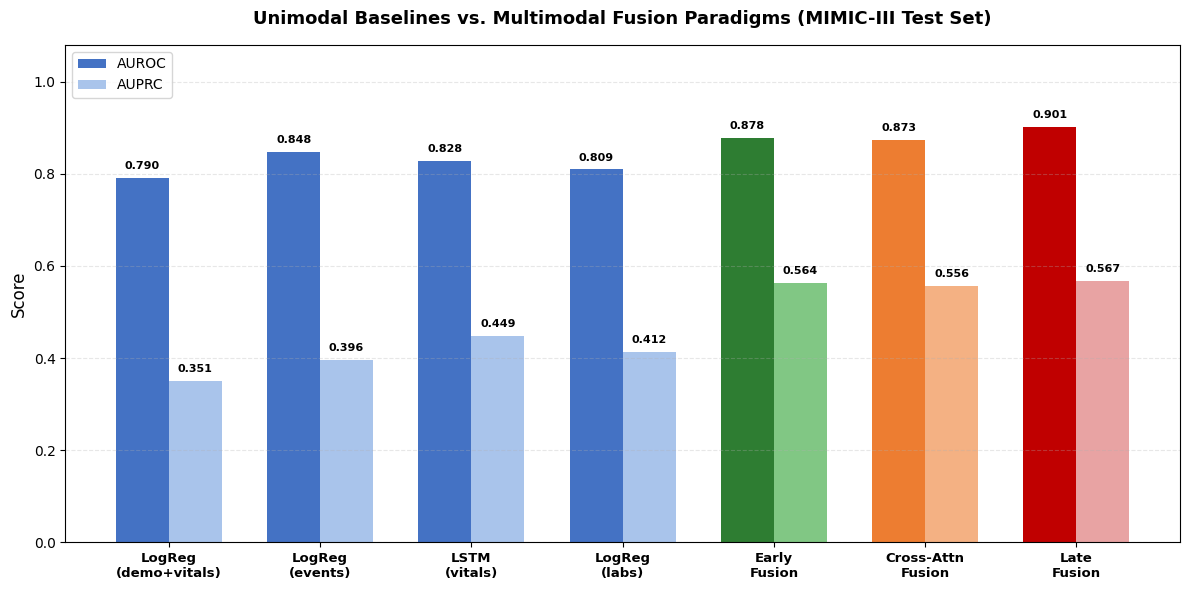

In [ ]:
# Models & Variable Alignment
models = [
    'LogReg\n(demo+vitals)',
    'LogReg\n(events)',
    'LSTM\n(vitals)',
    'LogReg\n(labs)',
    'Early\nFusion',
    'Cross-Attn\nFusion',
    'Late\nFusion'
]

p_lstm = np.array(probs_lstm).flatten()
p_labs = np.array(probs_labs_fair).flatten()

auroc_scores = [
    roc_auc_score(y_test_v, probs_v),
    roc_auc_score(y_test_e, probs_e),
    roc_auc_score(y_test_true, p_lstm),
    roc_auc_score(y_test_labs, p_labs),
    roc_auc_score(labels_te, probs_te),
    roc_auc_score(labels_attn_te, probs_attn_te),
    roc_auc_score(y_test_true, probs_late_fusion)
]

auprc_scores = [
    average_precision_score(y_test_v, probs_v),
    average_precision_score(y_test_e, probs_e),
    average_precision_score(y_test_true, p_lstm),
    average_precision_score(y_test_labs, p_labs),
    average_precision_score(labels_te, probs_te),
    average_precision_score(labels_attn_te, probs_attn_te),
    average_precision_score(y_test_true, probs_late_fusion)
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

colors_auroc = ['#4472C4']*4 + ['#2E7D32', '#ED7D31', '#C00000']
colors_auprc = ['#A9C4EB']*4 + ['#81C784', '#F4B183', '#E8A3A3']

b1 = ax.bar(x - width/2, auroc_scores, width, label='AUROC', color=colors_auroc)
b2 = ax.bar(x + width/2, auprc_scores, width, label='AUPRC', color=colors_auprc)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9.5, fontweight='bold')
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Unimodal Baselines vs. Multimodal Fusion Paradigms (MIMIC-III Test Set)', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.015, f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Statistical Comparison & Confidence Intervals

In [ ]:
def bootstrap_ci(y_true, y_pred, metric_func, n_bootstraps=1000, alpha=0.05, seed=42):
    np.random.seed(seed)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n = len(y_true)

    scores = []
    for _ in range(n_bootstraps):
        idx = np.random.choice(n, n, replace=True)
        y_true_bs = y_true[idx]
        y_pred_bs = y_pred[idx]
        if len(np.unique(y_true_bs)) < 2:
            continue
        scores.append(metric_func(y_true_bs, y_pred_bs))

    scores = np.array(scores)
    mean_score = scores.mean()
    lower = np.percentile(scores, 100 * alpha / 2)
    upper = np.percentile(scores, 100 * (1 - alpha / 2))
    return mean_score, lower, upper

## 5. Paired Bootstrap: Significance Testing

In [ ]:
def paired_bootstrap_test(y_true, probs_a, probs_b, metric_func, n_bootstraps=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.array(y_true)
    probs_a = np.array(probs_a)
    probs_b = np.array(probs_b)
    n = len(y_true)
    diffs = []

    for _ in range(n_bootstraps):
        idx = rng.integers(0, n, n)
        y_sample = y_true[idx]
        if len(np.unique(y_sample)) < 2:
            continue

        score_a = metric_func(y_sample, probs_a[idx])
        score_b = metric_func(y_sample, probs_b[idx])
        diffs.append(score_a - score_b)

    diffs = np.array(diffs)
    mean_diff = diffs.mean()
    lo = np.percentile(diffs, 2.5)
    hi = np.percentile(diffs, 97.5)

    # Two-sided empirical p-value
    p_val = 2 * min((diffs > 0).mean(), (diffs < 0).mean())
    p_val = min(p_val, 1.0)

    return mean_diff, lo, hi, p_val

pairs = [
    ("Late Fusion", "Early Fusion", y_test_true, probs_late_fusion, probs_te),
    ("Late Fusion", "Cross-Attention", y_test_true, probs_late_fusion, probs_attn_te),
    ("Cross-Attention", "Early Fusion", labels_attn_te, probs_attn_te, probs_te),
]

paired_results = []

for name_a, name_b, y_true, p_a, p_b in pairs:
    # AUROC Paired Difference
    mean_auc_d, auc_lo, auc_hi, auc_p = paired_bootstrap_test(y_true, p_a, p_b, roc_auc_score)

    # AUPRC Paired Difference
    mean_pr_d, pr_lo, pr_hi, pr_p = paired_bootstrap_test(y_true, p_a, p_b, average_precision_score)

    paired_results.append({
        "Comparison": f"{name_a} vs {name_b}",
        "Δ AUROC": f"{mean_auc_d:+.4f}",
        "AUROC 95% CI": f"[{auc_lo:+.4f}, {auc_hi:+.4f}]",
        "AUROC p-value": f"p={auc_p:.4f}",
        "Δ AUPRC": f"{mean_pr_d:+.4f}",
        "AUPRC 95% CI": f"[{pr_lo:+.4f}, {pr_hi:+.4f}]",
        "AUPRC p-value": f"p={pr_p:.4f}"
    })

df_paired = pd.DataFrame(paired_results)

display(df_paired)

,Comparison,Δ AUROC,AUROC 95% CI,AUROC p-value,Δ AUPRC,AUPRC 95% CI,AUPRC p-value
0,Late Fusion vs Early Fusion,+0.0233,"[+0.0112, +0.0357]",p=0.0000,+0.0028,"[-0.0291, +0.0346]",p=0.8600
1,Late Fusion vs Cross-Attention,+0.0279,"[+0.0149, +0.0408]",p=0.0000,+0.0105,"[-0.0251, +0.0428]",p=0.5380
2,Cross-Attention vs Early Fusion,-0.0046,"[-0.0173, +0.0079]",p=0.4620,-0.0077,"[-0.0339, +0.0169]",p=0.5680


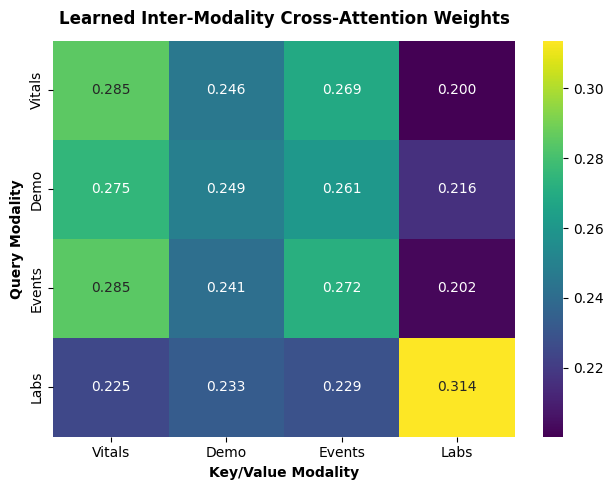

In [ ]:
model_cross_attn.eval()
modalities = ['Vitals', 'Demo', 'Events', 'Labs']

with torch.no_grad():
    for vb, lb, db, eb, lab_b, _ in fusion_test_loader:   
        vb, db, eb, lab_b = vb.to(device), db.to(device), eb.to(device), lab_b.to(device)

        # projection tokens
        v = model_cross_attn.proj_v(model_cross_attn.vitals_enc(vb, lb))
        d = model_cross_attn.proj_d(model_cross_attn.demo_enc(db))
        e = model_cross_attn.proj_e(model_cross_attn.events_enc(eb))
        l = model_cross_attn.proj_l(model_cross_attn.labs_enc(lab_b))

        tokens = torch.stack([v, d, e, l], dim=1)

        # Extract attention weights matrix (batch_size, 4, 4)
        _, attn_weights = model_cross_attn.attention(tokens, tokens, tokens)
        avg_attn = attn_weights.mean(dim=0).cpu().numpy()
        break

# Attention Heatmap
plt.figure(figsize=(6.5, 5))
sns.heatmap(avg_attn, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=modalities, yticklabels=modalities)
plt.title('Learned Inter-Modality Cross-Attention Weights', fontweight='bold', pad=12)
plt.xlabel('Key/Value Modality', fontweight='bold')
plt.ylabel('Query Modality', fontweight='bold')
plt.tight_layout()
plt.savefig('cross_attention_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Ablation Study: Modality Contribution Analysis

In [ ]:
import time
class AblationCrossAttentionModel(nn.Module):
    def __init__(self, active_modalities, vitals_input=6, demo_input=4, events_input=200, labs_input=33, embed_dim=32, n_heads=4):
        super().__init__()
        self.active_modalities = active_modalities

        # Encoders and projection layers
        self.encoders = nn.ModuleDict()
        self.projections = nn.ModuleDict()

        if 'vitals' in active_modalities:
            self.encoders['vitals'] = VitalsEncoder(input_size=vitals_input)
            self.projections['vitals'] = nn.Linear(32, embed_dim)
        if 'demo' in active_modalities:
            self.encoders['demo'] = DemoEncoder(input_size=demo_input, hidden_size=16)   # DemoEncoder outputs 16
            self.projections['demo'] = nn.Linear(16, embed_dim)
        if 'events' in active_modalities:
            self.encoders['events'] = EventsEncoder(input_size=events_input)
            self.projections['events'] = nn.Linear(32, embed_dim)
        if 'labs' in active_modalities:
            self.encoders['labs'] = LabsEncoder(input_size=labs_input)
            self.projections['labs'] = nn.Linear(32, embed_dim)

        n_modalities = len(active_modalities)
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=n_heads, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * n_modalities, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, inputs):
        embeddings = []
        if 'vitals' in self.active_modalities:
            v_x, v_len = inputs['vitals']
            v = self.encoders['vitals'](v_x, v_len)
            embeddings.append(self.projections['vitals'](v))
        if 'demo' in self.active_modalities:
            d = self.encoders['demo'](inputs['demo'])
            embeddings.append(self.projections['demo'](d))
        if 'events' in self.active_modalities:
            e = self.encoders['events'](inputs['events'])
            embeddings.append(self.projections['events'](e))
        if 'labs' in self.active_modalities:
            l = self.encoders['labs'](inputs['labs'])
            embeddings.append(self.projections['labs'](l))

        tokens = torch.stack(embeddings, dim=1)  # (batch, n_modalities, embed_dim)
        attended, _ = self.attention(tokens, tokens, tokens)
        attended = self.norm(attended + tokens)
        combined = attended.reshape(attended.shape[0], -1)
        return self.classifier(combined).squeeze(1)


def train_and_eval_ablation(active_modalities, seed=42, epochs=30, lr=1e-3, mask_prob=0.15):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Model Initialization
    model = AblationCrossAttentionModel(
        active_modalities=active_modalities,
        vitals_input=vitals_seq_train_d.shape[-1],
        demo_input=demo_train_t_d.shape[1],
        events_input=events_train_t_d.shape[1],
        labs_input=labs_train_t_d.shape[1]
    ).to(device)

    # Build input dictionaries
    train_inputs = {}
    test_inputs = {}
    if 'vitals' in active_modalities:
        train_inputs['vitals'] = (vitals_seq_train_d, vitals_len_train_d)
        test_inputs['vitals'] = (vitals_seq_test_d, vitals_len_test_d)
    if 'demo' in active_modalities:
        train_inputs['demo'] = demo_train_t_d
        test_inputs['demo'] = demo_test_t_d
    if 'events' in active_modalities:
        train_inputs['events'] = events_train_t_d
        test_inputs['events'] = events_test_t_d
    if 'labs' in active_modalities:
        train_inputs['labs'] = labs_train_t_d
        test_inputs['labs'] = labs_test_t_d

    # Loss & Optimizer
    pos_weight = torch.tensor(
        [(len(labels_train_t_d) - labels_train_t_d.sum()) / labels_train_t_d.sum()]
    ).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Training Loop
    target_train = labels_train_t_d.float().view(-1)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Apply masking to the current batch
        train_inputs_masked = {}
        if 'vitals' in active_modalities:
            v_x, v_len = train_inputs['vitals']
            mask_v = (torch.rand(v_x.size(0), 1, 1, device=device) > mask_prob).float()
            train_inputs_masked['vitals'] = (v_x * mask_v, v_len)
        if 'demo' in active_modalities:
            d = train_inputs['demo']
            mask_d = (torch.rand(d.size(0), 1, device=device) > mask_prob).float()
            train_inputs_masked['demo'] = d * mask_d
        if 'events' in active_modalities:
            e = train_inputs['events']
            mask_e = (torch.rand(e.size(0), 1, device=device) > mask_prob).float()
            train_inputs_masked['events'] = e * mask_e
        if 'labs' in active_modalities:
            l = train_inputs['labs']
            mask_l = (torch.rand(l.size(0), 1, device=device) > mask_prob).float()
            train_inputs_masked['labs'] = l * mask_l

        # Forward pass with masked inputs
        logits = model(train_inputs_masked).view(-1)
        loss = criterion(logits, target_train)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            print(f"    Epoch {epoch+1:02d}/{epochs} | Loss: {loss.item():.4f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        logits_test = model(test_inputs).view(-1)
        probs = torch.sigmoid(logits_test).cpu().numpy()

    auroc = roc_auc_score(y_test_true, probs)
    auprc = average_precision_score(y_test_true, probs)

    return auroc, auprc, probs

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vitals_seq_train_d = X_train_seq.to(device) if isinstance(X_train_seq, torch.Tensor) else torch.tensor(X_train_seq).float().to(device)
vitals_len_train_d = len_train_seq.to(device) if isinstance(len_train_seq, torch.Tensor) else torch.tensor(len_train_seq).long().to(device)

vitals_seq_test_d = X_test_seq.to(device) if isinstance(X_test_seq, torch.Tensor) else torch.tensor(X_test_seq).float().to(device)
vitals_len_test_d = len_test_seq.to(device) if isinstance(len_test_seq, torch.Tensor) else torch.tensor(len_test_seq).long().to(device)

demo_train_t_d = demo_train_t.to(device) if isinstance(demo_train_t, torch.Tensor) else torch.tensor(demo_train_t).float().to(device)
demo_test_t_d = demo_test_t.to(device) if isinstance(demo_test_t, torch.Tensor) else torch.tensor(demo_test_t).float().to(device)

events_train_t_d = events_train_t.to(device) if isinstance(events_train_t, torch.Tensor) else torch.tensor(events_train_t).float().to(device)
events_test_t_d = events_test_t.to(device) if isinstance(events_test_t, torch.Tensor) else torch.tensor(events_test_t).float().to(device)

labs_train_t_d = labs_train_t.to(device) if isinstance(labs_train_t, torch.Tensor) else torch.tensor(labs_train_t).float().to(device)
labs_test_t_d = labs_test_t.to(device) if isinstance(labs_test_t, torch.Tensor) else torch.tensor(labs_test_t).float().to(device)

labels_train_t_d = labels_train_t.to(device) if isinstance(labels_train_t, torch.Tensor) else torch.tensor(labels_train_t).float().to(device)
labels_test_t_d = labels_test_t.to(device) if isinstance(labels_test_t, torch.Tensor) else torch.tensor(labels_test_t).float().to(device)

y_test_true = labels_test_t_d.cpu().numpy()   # used for evaluation
print("All tensors mapped to device successfully!")

All tensors mapped to device successfully!


In [ ]:
all_modalities = ['vitals', 'demo', 'events', 'labs']
ablation_results = {}

print("Full model (all 4 modalities)")
probs_full = probs_attn_te
auroc = roc_auc_score(y_test_true, probs_full)
auprc = average_precision_score(y_test_true, probs_full)
print(f"  AUROC={auroc:.4f}  AUPRC={auprc:.4f}\n")
ablation_results['Full (all 4)'] = (auroc, auprc, probs_full)

for modality_to_remove in all_modalities:
    remaining = [m for m in all_modalities if m != modality_to_remove]
    print(f"Removing '{modality_to_remove}' -> using {remaining}:")
    start = time.time()
    auroc, auprc, probs = train_and_eval_ablation(remaining)
    print(f"  AUROC={auroc:.4f}  AUPRC={auprc:.4f}  ({time.time()-start:.1f}s)\n")
    ablation_results[f'Without {modality_to_remove}'] = (auroc, auprc, probs)

baseline_key = 'Full (all 4)'
full_auroc, full_auprc, _ = ablation_results[baseline_key]

table_data = []
for name, (auroc, auprc, _) in ablation_results.items():
    delta_auc = auroc - full_auroc
    delta_pr = auprc - full_auprc
    table_data.append({
        'Ablation Variant': name,
        'AUROC': f'{auroc:.4f}',
        'Δ AUROC': f'{delta_auc:+.4f}' if name != baseline_key else 'Base',
        'AUPRC': f'{auprc:.4f}',
        'Δ AUPRC': f'{delta_pr:+.4f}' if name != baseline_key else 'Base',
    })

df_ablation_summary = pd.DataFrame(table_data)
print("\n Ablation Summary ")
display(df_ablation_summary)

Full model (all 4 modalities)
  AUROC=0.8734  AUPRC=0.5563

Removing 'vitals' -> using ['demo', 'events', 'labs']:
    Epoch 10/30 | Loss: 1.0843
    Epoch 20/30 | Loss: 0.9123
    Epoch 30/30 | Loss: 0.8314
  AUROC=0.8835  AUPRC=0.4609  (10.0s)

Removing 'demo' -> using ['vitals', 'events', 'labs']:
    Epoch 10/30 | Loss: 1.0721
    Epoch 20/30 | Loss: 0.9446
    Epoch 30/30 | Loss: 0.8477
  AUROC=0.8854  AUPRC=0.5339  (491.1s)

Removing 'events' -> using ['vitals', 'demo', 'labs']:
    Epoch 10/30 | Loss: 1.1163
    Epoch 20/30 | Loss: 1.0144
    Epoch 30/30 | Loss: 0.9699
  AUROC=0.8458  AUPRC=0.4802  (494.0s)

Removing 'labs' -> using ['vitals', 'demo', 'events']:
    Epoch 10/30 | Loss: 1.1208
    Epoch 20/30 | Loss: 0.9405
    Epoch 30/30 | Loss: 0.8550
  AUROC=0.8764  AUPRC=0.5027  (496.1s)


 Ablation Summary 


,Ablation Variant,AUROC,Δ AUROC,AUPRC,Δ AUPRC
0,Full (all 4),0.8734,Base,0.5563,Base
1,Without vitals,0.8835,+0.0100,0.4609,-0.0954
2,Without demo,0.8854,+0.0120,0.5339,-0.0224
3,Without events,0.8458,-0.0277,0.4802,-0.0761
4,Without labs,0.8764,+0.0029,0.5027,-0.0536


In [ ]:
print(f"{'Model':<20} {'Mean AUROC':<12} {'95% CI'}")
for name, (auroc, auprc, probs) in ablation_results.items():
    mean_score, lo, hi = bootstrap_ci(y_test_true, probs, roc_auc_score)
    print(f"{name:<20} {mean_score:.4f}       [{lo:.4f}, {hi:.4f}]")

print("\n Does removing each modality significantly hurt performance?")
print(f"{'Comparison':<30} {'Mean Diff':<12} {'95% CI':<22} {'p-value'}")

probs_full = ablation_results['Full (all 4)'][2]

for name in ['Without vitals', 'Without demo', 'Without events', 'Without labs']:
    probs_ablated = ablation_results[name][2]
    mean_diff, lo, hi, p_value = paired_bootstrap_test(y_test_true, probs_full, probs_ablated, roc_auc_score)
    label = f"Full - {name}"
    print(f"{label:<30} {mean_diff:+.4f}      [{lo:+.4f}, {hi:+.4f}]   p={p_value:.4f}")

Model                Mean AUROC   95% CI
Full (all 4)         0.8732       [0.8575, 0.8871]
Without vitals       0.8828       [0.8702, 0.8948]
Without demo         0.8847       [0.8707, 0.8970]
Without events       0.8451       [0.8295, 0.8600]
Without labs         0.8758       [0.8611, 0.8891]

 Does removing each modality significantly hurt performance?
Comparison                     Mean Diff    95% CI                 p-value
Full - Without vitals          -0.0101      [-0.0222, +0.0014]   p=0.1200
Full - Without demo            -0.0121      [-0.0248, -0.0003]   p=0.0480
Full - Without events          +0.0276      [+0.0109, +0.0449]   p=0.0000
Full - Without labs            -0.0029      [-0.0153, +0.0096]   p=0.6620


In [ ]:
import pickle
with open(f'{save_dir}/ablation_results.pkl', 'wb') as f:
    pickle.dump({k: (v[0], v[1], v[2]) for k, v in ablation_results.items()}, f)
print("saved ablation results")

saved ablation results


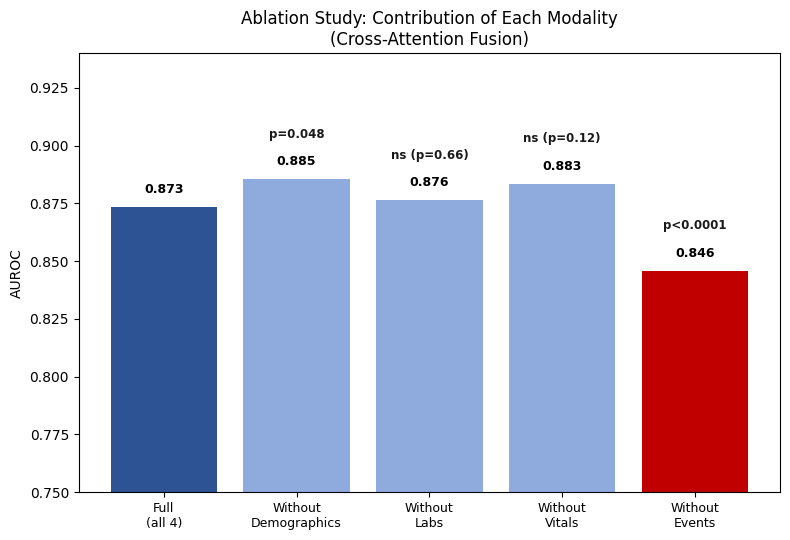

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def get_pvalue_label(name):
    if name == 'Full (all 4)':
        return ''
    probs_full = ablation_results['Full (all 4)'][2]
    probs_ablated = ablation_results[name][2]
    _, _, _, p = paired_bootstrap_test(y_test_true, probs_full, probs_ablated, roc_auc_score)
    if p < 0.0001:
        return 'p<0.0001'
    elif p < 0.05:
        return f'p={p:.3f}'
    else:
        return f'ns (p={p:.2f})'

model_keys = ['Full (all 4)', 'Without demo', 'Without labs', 'Without vitals', 'Without events']
labels = ['Full\n(all 4)', 'Without\nDemographics', 'Without\nLabs', 'Without\nVitals', 'Without\nEvents']

aurocs_plot = [ablation_results[k][0] for k in model_keys]
significance_labels = [get_pvalue_label(k) for k in model_keys]

colors = ['#2E5395', '#8FAADC', '#8FAADC', '#8FAADC', '#C00000']

fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(len(labels))
bars = ax.bar(x, aurocs_plot, color=colors)
ax.set_ylim(0.75, 0.94)
ax.set_ylabel('AUROC')
ax.set_title('Ablation Study: Contribution of Each Modality\n(Cross-Attention Fusion)')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)

for bar, val, sig in zip(bars, aurocs_plot, significance_labels):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.006, f'{val:.3f}', ha='center', fontsize=9, fontweight='bold', color='black')
    if sig:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.018, sig, ha='center', fontsize=8.5, fontweight='bold', color='#1a1a1a')

plt.tight_layout()
plt.savefig('ablation_chart.png', dpi=150)
plt.show()

In [ ]:
print(" RQ1: Does fusion significantly beat the best single modality?\n")

comparisons_rq1 = [
    ("Late Fusion", "LogReg (discrete events)", probs_late_fusion, probs_e),
    ("Cross-Attention Fusion", "LogReg (discrete events)", probs_attn_te, probs_e),
    ("Early Fusion", "LogReg (discrete events)", probs_te, probs_e),  
]

print(f"{'Comparison':<45} {'Mean Diff':<12} {'95% CI':<22} {'p-value'}")
for name_a, name_b, probs_a, probs_b in comparisons_rq1:
    mean_diff, lo, hi, p_value = paired_bootstrap_test(y_test_true, probs_a, probs_b, roc_auc_score)
    label = f"{name_a} - {name_b}"
    print(f"{label:<45} {mean_diff:+.4f}      [{lo:+.4f}, {hi:+.4f}]   p={p_value:.4f}")

 RQ1: Does fusion significantly beat the best single modality?

Comparison                                    Mean Diff    95% CI                 p-value
Late Fusion - LogReg (discrete events)        +0.0533      [+0.0423, +0.0643]   p=0.0000
Cross-Attention Fusion - LogReg (discrete events) +0.0254      [+0.0120, +0.0391]   p=0.0000
Early Fusion - LogReg (discrete events)       +0.0300      [+0.0169, +0.0423]   p=0.0000


In [ ]:
results_table = pd.DataFrame([
    # Unimodal baselines
    {"Category": "Unimodal", "Model": "LogReg (vitals + demographics)", "AUROC": roc_auc_score(y_test_v, probs_v), "AUPRC": average_precision_score(y_test_v, probs_v)},
    {"Category": "Unimodal", "Model": "LogReg (discrete events)", "AUROC": roc_auc_score(y_test_e, probs_e), "AUPRC": average_precision_score(y_test_e, probs_e)},
    {"Category": "Unimodal", "Model": "LSTM (vitals)", "AUROC": roc_auc_score(labels_lstm, probs_lstm), "AUPRC": average_precision_score(labels_lstm, probs_lstm)},
    {"Category": "Unimodal", "Model": "LogReg (labs)", "AUROC": roc_auc_score(y_test_labs, probs_labs_fair), "AUPRC": average_precision_score(y_test_labs, probs_labs_fair)},

    # Fusion strategies
    {"Category": "Fusion", "Model": "Early Fusion", "AUROC": roc_auc_score(y_test_true, probs_te), "AUPRC": average_precision_score(y_test_true, probs_te)},
    {"Category": "Fusion", "Model": "Late Fusion", "AUROC": roc_auc_score(y_test_true, probs_late_fusion), "AUPRC": average_precision_score(y_test_true, probs_late_fusion)},
    {"Category": "Fusion", "Model": "Cross-Attention Fusion", "AUROC": roc_auc_score(y_test_true, probs_attn_te), "AUPRC": average_precision_score(y_test_true, probs_attn_te)},

    # Ablation (cross-attention base)
    {"Category": "Ablation", "Model": "Full (all 4 modalities)", "AUROC": ablation_results['Full (all 4)'][0], "AUPRC": ablation_results['Full (all 4)'][1]},
    {"Category": "Ablation", "Model": "Without vitals", "AUROC": ablation_results['Without vitals'][0], "AUPRC": ablation_results['Without vitals'][1]},
    {"Category": "Ablation", "Model": "Without demographics", "AUROC": ablation_results['Without demo'][0], "AUPRC": ablation_results['Without demo'][1]},
    {"Category": "Ablation", "Model": "Without discrete events", "AUROC": ablation_results['Without events'][0], "AUPRC": ablation_results['Without events'][1]},
    {"Category": "Ablation", "Model": "Without labs", "AUROC": ablation_results['Without labs'][0], "AUPRC": ablation_results['Without labs'][1]},
])

results_table["AUROC"] = results_table["AUROC"].round(4)
results_table["AUPRC"] = results_table["AUPRC"].round(4)

results_table.to_csv(f'{save_dir}/consolidated_results_table.csv', index=False)
print("saved consolidated_results_table.csv to Drive\n")
display(results_table)

saved consolidated_results_table.csv to Drive



,Category,Model,AUROC,AUPRC
0,Unimodal,LogReg (vitals + demographics),0.7902,0.3507
1,Unimodal,LogReg (discrete events),0.8479,0.3959
2,Unimodal,LSTM (vitals),0.8282,0.4487
3,Unimodal,LogReg (labs),0.8094,0.4124
4,Fusion,Early Fusion,0.8778,0.5636
5,Fusion,Late Fusion,0.9013,0.5667
6,Fusion,Cross-Attention Fusion,0.8734,0.5563
7,Ablation,Full (all 4 modalities),0.8734,0.5563
8,Ablation,Without vitals,0.8835,0.4609
9,Ablation,Without demographics,0.8854,0.5339


## 7. Calibration: Setup & Baseline

In [ ]:
import pickle

all_results_to_save = {
    'baselines': {
        'vitals_demo': {'probs': probs_v, 'y_true': y_test_v.values},
        'discrete_events': {'probs': probs_e, 'y_true': y_test_e.values},
        'lstm_vitals': {'probs': np.array(probs_lstm).flatten(), 'y_true': labels_lstm},
        'labs': {'probs': probs_labs_fair, 'y_true': y_test_labs.values},
    },
    'fusion': {
        'early_fusion': {'probs': probs_te, 'y_true': y_test_true},
        'late_fusion': {'probs': probs_late_fusion, 'y_true': y_test_true},
        'cross_attention': {'probs': probs_attn_te, 'y_true': y_test_true},
    },
    'ablation_results': ablation_results,
}

with open(f'{save_dir}/all_fusion_results.pkl', 'wb') as f:
    pickle.dump(all_results_to_save, f)

print("saved all_fusion_results.pkl to Drive")
print("contents:", list(all_results_to_save.keys()))

saved all_fusion_results.pkl to Drive
contents: ['baselines', 'fusion', 'ablation_results']


## 8. Platt Scaling & Calibration Evaluation

In [ ]:
train_ids_sub, val_ids = train_test_split(
    train_ids, test_size=0.15, stratify=[labels_lookup[s] for s in train_ids], random_state=42
)

print("train (for tuning):", len(train_ids_sub), "| validation:", len(val_ids), "| test (untouched):", len(test_ids))

def build_tensors_for_ids(ids_list):
    idx_map = {sid: i for i, sid in enumerate(stay_ids_used)}
    seq_idx = [idx_map[s] for s in ids_list if s in idx_map]

    vitals_seq = torch.tensor((X_seq[seq_idx] - train_mean) / train_std, dtype=torch.float32)
    vitals_len = torch.tensor(lengths[seq_idx], dtype=torch.long)

    demo_vals = demo_df.loc[ids_list].astype(float)
    demo_vals_s = demo_scaler.transform(demo_vals)
    demo_t = torch.tensor(demo_vals_s, dtype=torch.float32)

    events_vals = model_df_ev.loc[ids_list, feature_cols_ev]
    events_t = torch.tensor(events_vals.values, dtype=torch.float32)

    labs_vals = model_df_labs.loc[ids_list, feature_cols_labs]
    labs_vals_imp = labs_imputer.transform(labs_vals)
    labs_vals_s = labs_scaler.transform(labs_vals_imp)
    labs_t = torch.tensor(labs_vals_s, dtype=torch.float32)

    y_t = torch.tensor([labels_lookup[s] for s in ids_list], dtype=torch.float32)

    return vitals_seq.to(device), vitals_len, demo_t.to(device), events_t.to(device), labs_t.to(device), y_t.to(device)

vitals_tr, vlen_tr, demo_tr, events_tr, labs_tr, y_tr = build_tensors_for_ids(train_ids_sub)
vitals_va, vlen_va, demo_va, events_va, labs_va, y_va = build_tensors_for_ids(val_ids)

print("shapes — train:", vitals_tr.shape, "| val:", vitals_va.shape)

train (for tuning): 21788 | validation: 3846 | test (untouched): 6409
shapes — train: torch.Size([21788, 48, 7]) | val: torch.Size([3846, 48, 7])


In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

try:
    probs_late_fusion_cal
except NameError:
    X_v_cal = model_df.loc[train_ids_cal, feature_cols_vitals]
    X_v_cal_imp = imputer.transform(X_v_cal)
    X_v_cal_s = scaler.transform(X_v_cal_imp)
    probs_v_cal = logreg_v.predict_proba(X_v_cal_s)[:, 1]

    X_e_cal = model_df_ev.loc[train_ids_cal, feature_cols_ev]
    probs_e_cal = logreg_e.predict_proba(X_e_cal)[:, 1]

    idx_map = {sid: i for i, sid in enumerate(stay_ids_used)}
    cal_seq_idx = [idx_map[s] for s in train_ids_cal if s in idx_map]
    X_seq_cal = X_seq[cal_seq_idx]
    len_cal = lengths[cal_seq_idx]
    X_seq_cal_norm = (X_seq_cal - train_mean) / train_std
    model_lstm.eval()
    with torch.no_grad():
        logits_lstm_cal = model_lstm(torch.tensor(X_seq_cal_norm, dtype=torch.float32).to(device), torch.tensor(len_cal, dtype=torch.long))
        probs_lstm_cal = torch.sigmoid(logits_lstm_cal).cpu().numpy()

    X_l_cal = model_df_labs.loc[train_ids_cal, feature_cols_labs]
    X_l_cal_imp = labs_imputer.transform(X_l_cal)
    X_l_cal_s = labs_scaler.transform(X_l_cal_imp)
    probs_labs_cal = logreg_labs_fair.predict_proba(X_l_cal_s)[:, 1]

    probs_late_fusion_cal = np.mean([probs_v_cal, probs_e_cal, probs_lstm_cal, probs_labs_cal], axis=0)

    vitals_cal, vlen_cal, demo_cal, events_cal, labs_cal, y_cal_tensor = build_tensors_for_ids(train_ids_cal)
    model_cross_attn.eval()
    with torch.no_grad():
        logits_cal = model_cross_attn(vitals_cal.to(device), vlen_cal, demo_cal.to(device), events_cal.to(device), labs_cal.to(device))
        probs_cross_attn_cal = torch.sigmoid(logits_cal).cpu().numpy()
    y_cal_np = y_cal_tensor.cpu().numpy()
else:
    try:
        y_cal_np
    except NameError:
        vitals_cal, vlen_cal, demo_cal, events_cal, labs_cal, y_cal_tensor = build_tensors_for_ids(train_ids_cal)
        y_cal_np = y_cal_tensor.cpu().numpy()

cal_late = CalibratedClassifierCV(estimator=None, method='sigmoid', cv=5)
cal_late.fit(probs_late_fusion_cal.reshape(-1, 1), y_cal_np)
probs_late_fusion_calibrated = cal_late.predict_proba(probs_late_fusion.reshape(-1, 1))[:, 1]

cal_ca = CalibratedClassifierCV(estimator=None, method='sigmoid', cv=5)
cal_ca.fit(probs_cross_attn_cal.reshape(-1, 1), y_cal_np)
probs_ca_calibrated = cal_ca.predict_proba(np.array(probs_attn_te).reshape(-1, 1))[:, 1]

print(f"Late Fusion Brier (CV): {brier_score_loss(y_test_true, probs_late_fusion_calibrated):.4f}")
print(f"Cross-Attention Brier (CV): {brier_score_loss(y_test_true, probs_ca_calibrated):.4f}")

Late Fusion Brier (CV): 0.0611
Cross-Attention Brier (CV): 0.0664


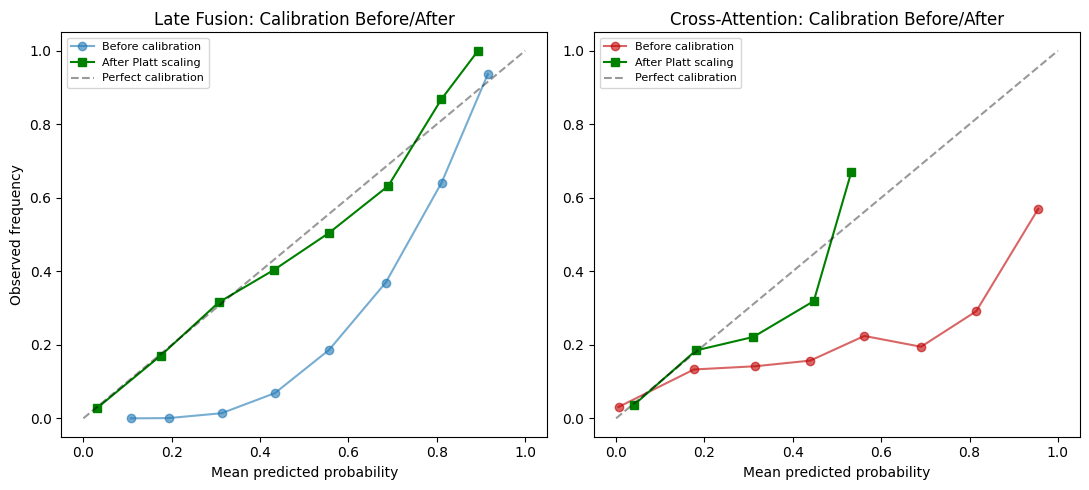

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Late Fusion: before vs after
frac_before_lf, mean_before_lf = calibration_curve(y_test_true, probs_late_fusion, n_bins=8)
frac_after_lf, mean_after_lf = calibration_curve(y_test_true, probs_late_fusion_calibrated, n_bins=8)
axes[0].plot(mean_before_lf, frac_before_lf, marker='o', label='Before calibration', alpha=0.6)
axes[0].plot(mean_after_lf, frac_after_lf, marker='s', label='After Platt scaling', color='green')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Observed frequency')
axes[0].set_title('Late Fusion: Calibration Before/After')
axes[0].legend(fontsize=8)

# Cross-Attention: before vs after
frac_before_ca, mean_before_ca = calibration_curve(y_test_true, probs_attn_te, n_bins=8)
frac_after_ca, mean_after_ca = calibration_curve(y_test_true, probs_ca_calibrated, n_bins=8)
axes[1].plot(mean_before_ca, frac_before_ca, marker='o', label='Before calibration', alpha=0.6, color='#C00000')
axes[1].plot(mean_after_ca, frac_after_ca, marker='s', label='After Platt scaling', color='green')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_title('Cross-Attention: Calibration Before/After')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import brier_score_loss

print("Brier Score (lower = better calibrated):\n")
print(f"Late Fusion       — before: {brier_score_loss(y_test_true, probs_late_fusion):.4f}   after: {brier_score_loss(y_test_true, probs_late_fusion_calibrated):.4f}")
print(f"Cross-Attention    — before: {brier_score_loss(y_test_true, probs_attn_te):.4f}   after: {brier_score_loss(y_test_true, probs_ca_calibrated):.4f}")

print("\nAUROC unchanged by calibration (as expected, since Platt scaling preserves ranking):")
print(f"Late Fusion AUROC — before: {roc_auc_score(y_test_true, probs_late_fusion):.4f}   after: {roc_auc_score(y_test_true, probs_late_fusion_calibrated):.4f}")
print(f"Cross-Attention AUROC — before: {roc_auc_score(y_test_true, probs_attn_te):.4f}   after: {roc_auc_score(y_test_true, probs_ca_calibrated):.4f}")

Brier Score (lower = better calibrated):

Late Fusion       — before: 0.1496   after: 0.0611
Cross-Attention    — before: 0.0982   after: 0.0664

AUROC unchanged by calibration (as expected, since Platt scaling preserves ranking):
Late Fusion AUROC — before: 0.9013   after: 0.9013
Cross-Attention AUROC — before: 0.8734   after: 0.8734


## 9. Interpretability: Cross‑Attention Weight Analysis

In [ ]:
def get_attention_weights(model, vitals_x, vitals_len, demo_x, events_x, labs_x):
    model.eval()
    with torch.no_grad():
        v = model.vitals_enc(vitals_x, vitals_len)
        d = model.demo_enc(demo_x)
        e = model.events_enc(events_x)
        l = model.labs_enc(labs_x)

        v = model.proj_v(v)
        d = model.proj_d(d)
        e = model.proj_e(e)
        l = model.proj_l(l)

        tokens = torch.stack([v, d, e, l], dim=1)
        attended, attn_weights = model.attention(tokens, tokens, tokens, average_attn_weights=False)
    return attn_weights.cpu().numpy()

attn_weights_all = get_attention_weights(
    model_cross_attn,
    vitals_seq_test_d,
    vitals_len_test_d,
    demo_test_t_d,
    events_test_t_d,
    labs_test_t_d
)

print("Attention weights shape:", attn_weights_all.shape)

attn_weights_avg_heads = attn_weights_all.mean(axis=1)
print("After averaging heads:", attn_weights_avg_heads.shape)

Attention weights shape: (6409, 4, 4, 4)
After averaging heads: (6409, 4, 4)


In [ ]:
import torch
import numpy as np

def train_cross_attn_once(seed):
    torch.manual_seed(seed)

    model = CrossAttentionFusionModel(
        vitals_input=X_train_seq.shape[-1],
        demo_input=demo_train_t.shape[1],
        events_input=events_train_t.shape[1],
        labs_input=labs_train_t.shape[1],
        embed_dim=32,
        n_heads=4
    ).to(device)

    pos_weight = torch.tensor(
        [(len(labels_train_t) - labels_train_t.sum()) / labels_train_t.sum()]
    ).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    EPOCHS = 30
    for epoch in range(EPOCHS):
        model.train()
        for vb, lb, db, eb, lab_b, yb in fusion_train_loader:
            vb, db, eb, lab_b, yb = vb.to(device), db.to(device), eb.to(device), lab_b.to(device), yb.to(device)
            vb, db, eb, lab_b = apply_modality_masking(vb, db, eb, lab_b, mask_prob=0.15)
            optimizer.zero_grad()
            logits = model(vb, lb, db, eb, lab_b)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
        print(f"  seed {seed} epoch {epoch+1}/{EPOCHS}")

    return model


def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1 - 1) * group1.std()**2 + (n2 - 1) * group2.std()**2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std


modality_labels_local = ['Vitals', 'Demographics', 'Events', 'Labs']

seed_results = {m: {'surv': [], 'nonsurv': []} for m in modality_labels_local}
seed_results_full = {m: {'surv': [], 'nonsurv': []} for m in modality_labels_local}
all_seed_matrices = []  

y_test_arr = np.array(y_test_true)
survivor_mask = y_test_arr == 0
nonsurvivor_mask = y_test_arr == 1

for seed in range(5):
    print(f"Training seed {seed}...")
    model_seed = train_cross_attn_once(seed)

    attn_weights_all_seed = get_attention_weights(
        model_seed,
        vitals_seq_test_d,
        vitals_len_test_d,
        demo_test_t_d,
        events_test_t_d,
        labs_test_t_d
    )
    attn_avg_heads_seed = attn_weights_all_seed.mean(axis=1)  

    all_seed_matrices.append(attn_avg_heads_seed.mean(axis=0)) 

    attn_received_seed = attn_avg_heads_seed.mean(axis=1)      

    for i, mod in enumerate(modality_labels_local):
        surv_vals = attn_received_seed[survivor_mask, i]
        nonsurv_vals = attn_received_seed[nonsurvivor_mask, i]

        seed_results[mod]['surv'].append(surv_vals.mean())
        seed_results[mod]['nonsurv'].append(nonsurv_vals.mean())

        seed_results_full[mod]['surv'].append(surv_vals)
        seed_results_full[mod]['nonsurv'].append(nonsurv_vals)

print(f"\n{'Modality':<15}{'Surv (mean±SD)':<22}{'Non-Surv (mean±SD)':<22}")
for mod in modality_labels_local:
    s = np.array(seed_results[mod]['surv'])
    ns = np.array(seed_results[mod]['nonsurv'])
    print(f"{mod:<15}{s.mean():.4f} ± {s.std():.4f}        {ns.mean():.4f} ± {ns.std():.4f}")

print(f"\n{'Modality':<15}{'Cohen d (mean ± SD across seeds)':<35}{'Interpretation'}")
for mod in modality_labels_local:
    d_values = []
    for seed_idx in range(5):
        surv_arr = seed_results_full[mod]['surv'][seed_idx]
        nonsurv_arr = seed_results_full[mod]['nonsurv'][seed_idx]
        d_values.append(cohens_d(surv_arr, nonsurv_arr))
    d_values = np.array(d_values)
    mean_d = d_values.mean()
    std_d = d_values.std()
    interp = "negligible" if abs(mean_d) < 0.2 else "small" if abs(mean_d) < 0.5 else "medium" if abs(mean_d) < 0.8 else "large"
    print(f"{mod:<15}{mean_d:.3f} ± {std_d:.3f}{'':<20}{interp}")

Training seed 0...
  seed 0 epoch 1/30
  seed 0 epoch 2/30
  seed 0 epoch 3/30
  seed 0 epoch 4/30
  seed 0 epoch 5/30
  seed 0 epoch 6/30
  seed 0 epoch 7/30
  seed 0 epoch 8/30
  seed 0 epoch 9/30
  seed 0 epoch 10/30
  seed 0 epoch 11/30
  seed 0 epoch 12/30
  seed 0 epoch 13/30
  seed 0 epoch 14/30
  seed 0 epoch 15/30
  seed 0 epoch 16/30
  seed 0 epoch 17/30
  seed 0 epoch 18/30
  seed 0 epoch 19/30
  seed 0 epoch 20/30
  seed 0 epoch 21/30
  seed 0 epoch 22/30
  seed 0 epoch 23/30
  seed 0 epoch 24/30
  seed 0 epoch 25/30
  seed 0 epoch 26/30
  seed 0 epoch 27/30
  seed 0 epoch 28/30
  seed 0 epoch 29/30
  seed 0 epoch 30/30
Training seed 1...
  seed 1 epoch 1/30
  seed 1 epoch 2/30
  seed 1 epoch 3/30
  seed 1 epoch 4/30
  seed 1 epoch 5/30
  seed 1 epoch 6/30
  seed 1 epoch 7/30
  seed 1 epoch 8/30
  seed 1 epoch 9/30
  seed 1 epoch 10/30
  seed 1 epoch 11/30
  seed 1 epoch 12/30
  seed 1 epoch 13/30
  seed 1 epoch 14/30
  seed 1 epoch 15/30
  seed 1 epoch 16/30
  seed 1 epoch

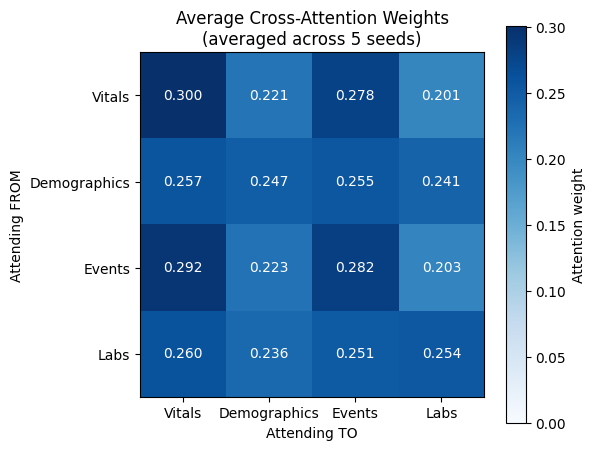

In [ ]:
modality_labels = ['Vitals', 'Demographics', 'Events', 'Labs']

overall_avg_attn = np.mean(all_seed_matrices, axis=0)  # (4, 4), averaged across 5 seeds

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(overall_avg_attn, cmap='Blues', vmin=0, vmax=overall_avg_attn.max())
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(modality_labels)
ax.set_yticklabels(modality_labels)
ax.set_xlabel('Attending TO')
ax.set_ylabel('Attending FROM')
ax.set_title('Average Cross-Attention Weights\n(averaged across 5 seeds)')

for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{overall_avg_attn[i,j]:.3f}', ha='center', va='center',
                color='white' if overall_avg_attn[i,j] > overall_avg_attn.max()/2 else 'black')

plt.colorbar(im, ax=ax, label='Attention weight')
plt.tight_layout()
plt.show()

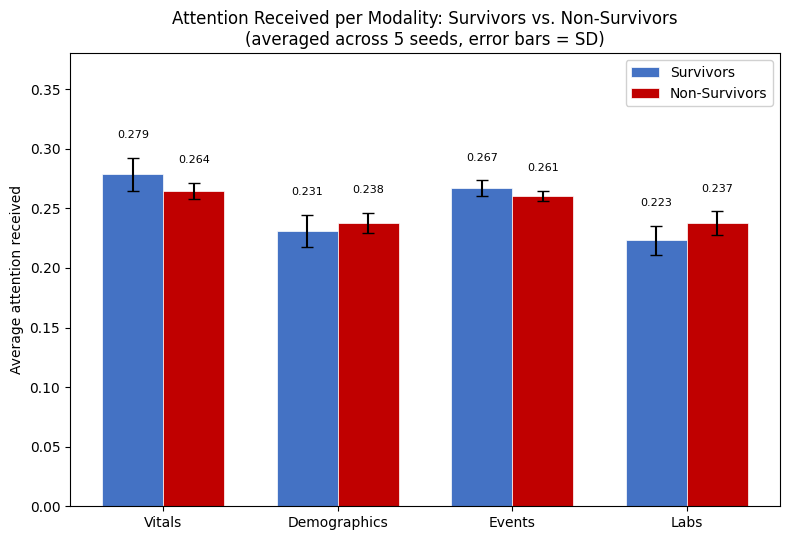

In [ ]:
modality_labels_local = ['Vitals', 'Demographics', 'Events', 'Labs']

means_survivor = np.array([np.mean(seed_results[m]['surv']) for m in modality_labels_local])
std_survivor   = np.array([np.std(seed_results[m]['surv']) for m in modality_labels_local])
means_nonsurvivor = np.array([np.mean(seed_results[m]['nonsurv']) for m in modality_labels_local])
std_nonsurvivor   = np.array([np.std(seed_results[m]['nonsurv']) for m in modality_labels_local])

fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(4)
width = 0.35

bars1 = ax.bar(x - width/2, means_survivor, width, yerr=std_survivor, capsize=4,
               label='Survivors', color='#4472C4', edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, means_nonsurvivor, width, yerr=std_nonsurvivor, capsize=4,
               label='Non-Survivors', color='#C00000', edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(modality_labels_local)
ax.set_ylabel('Average attention received')
ax.set_title('Attention Received per Modality: Survivors vs. Non-Survivors\n(averaged across 5 seeds, error bars = SD)')

for bar, val, err in zip(bars1, means_survivor, std_survivor):
    ax.text(bar.get_x() + bar.get_width()/2., val + err + 0.015,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

for bar, val, err in zip(bars2, means_nonsurvivor, std_nonsurvivor):
    ax.text(bar.get_x() + bar.get_width()/2., val + err + 0.015,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.legend(loc='upper right', frameon=True, framealpha=0.9)

max_top = max((means_survivor + std_survivor).max(), (means_nonsurvivor + std_nonsurvivor).max())
ax.set_ylim(0, max_top * 1.3)

plt.tight_layout()
plt.show()

## 10. Robustness to Missing Modalities

In [ ]:
def simulate_missing_modality(model, missing_modality):
    """Zero out one modality's input to the FULL trained model, simulating it being unavailable at inference."""
    model.eval()

    vitals_in = vitals_seq_test_d.clone()
    demo_in = demo_test_t_d.clone()
    events_in = events_test_t_d.clone()
    labs_in = labs_test_t_d.clone()

    if missing_modality == 'vitals':
        vitals_in = torch.zeros_like(vitals_in)
    elif missing_modality == 'demo':
        demo_in = torch.zeros_like(demo_in)
    elif missing_modality == 'events':
        events_in = torch.zeros_like(events_in)
    elif missing_modality == 'labs':
        labs_in = torch.zeros_like(labs_in)

    with torch.no_grad():
        logits = model(vitals_in, vitals_len_test_d, demo_in, events_in, labs_in) 
        probs = torch.sigmoid(logits).cpu().numpy()

    return roc_auc_score(y_test_true, probs), average_precision_score(y_test_true, probs)

print("Robustness of the FULL cross-attention model when one modality goes missing AT INFERENCE\n")

print(f"{'Scenario':<30} {'AUROC':<10} {'AUPRC':<10}")

auroc_full = roc_auc_score(y_test_true, probs_attn_te) 
auprc_full = average_precision_score(y_test_true, probs_attn_te)
print(f"{'Full model, no missingness':<30} {auroc_full:<10.4f} {auprc_full:<10.4f}")

missing_results = {}
for modality in ['vitals', 'demo', 'events', 'labs']:
    auroc, auprc = simulate_missing_modality(model_cross_attn, modality)
    print(f"{'Missing: ' + modality:<30} {auroc:<10.4f} {auprc:<10.4f}")
    missing_results[modality] = (auroc, auprc)

Robustness of the FULL cross-attention model when one modality goes missing AT INFERENCE

Scenario                       AUROC      AUPRC     
Full model, no missingness     0.8734     0.5563    
Missing: vitals                0.8514     0.4657    
Missing: demo                  0.8639     0.5451    
Missing: events                0.8726     0.5698    
Missing: labs                  0.8407     0.4802    


## 11. Per‑Case Attribution (Illustrative Patients)

In [ ]:
y_true_arr = np.array(y_test_true)
probs_arr = np.array(probs_attn_te)
attn_received_per_patient = attn_weights_avg_heads.mean(axis=1)

def find_case(condition_mask, sort_by, ascending=False):
    idx_candidates = np.where(condition_mask)[0]
    sorted_idx = idx_candidates[np.argsort(probs_arr[idx_candidates])]
    return sorted_idx[0] if ascending else sorted_idx[-1]

tp_idx = find_case((y_true_arr == 1) & (probs_arr > 0.5), probs_arr)
tn_idx = find_case((y_true_arr == 0) & (probs_arr < 0.5), probs_arr, ascending=True)
fn_idx = find_case((y_true_arr == 1) & (probs_arr < 0.5), probs_arr, ascending=True)
fp_idx = find_case((y_true_arr == 0) & (probs_arr > 0.5), probs_arr)

cases = {
    'True Positive': tp_idx,
    'True Negative': tn_idx,
    'False Negative': fn_idx,
    'False Positive': fp_idx,
}

print(f"{'Case':<20} {'True':<6} {'Pred':<8} {'Vitals':<8} {'Demo':<8} {'Events':<8} {'Labs'}")
for case_name, idx in cases.items():
    attn = attn_received_per_patient[idx]
    print(f"{case_name:<20} {y_true_arr[idx]:<6} {probs_arr[idx]:<8.3f} {attn[0]:<8.3f} {attn[1]:<8.3f} {attn[2]:<8.3f} {attn[3]:.3f}")

Case                 True   Pred     Vitals   Demo     Events   Labs
True Positive        1.0    0.999    0.255    0.242    0.237    0.265
True Negative        0.0    0.000    0.268    0.241    0.266    0.225
False Negative       1.0    0.000    0.277    0.240    0.261    0.223
False Positive       0.0    0.997    0.232    0.228    0.231    0.309


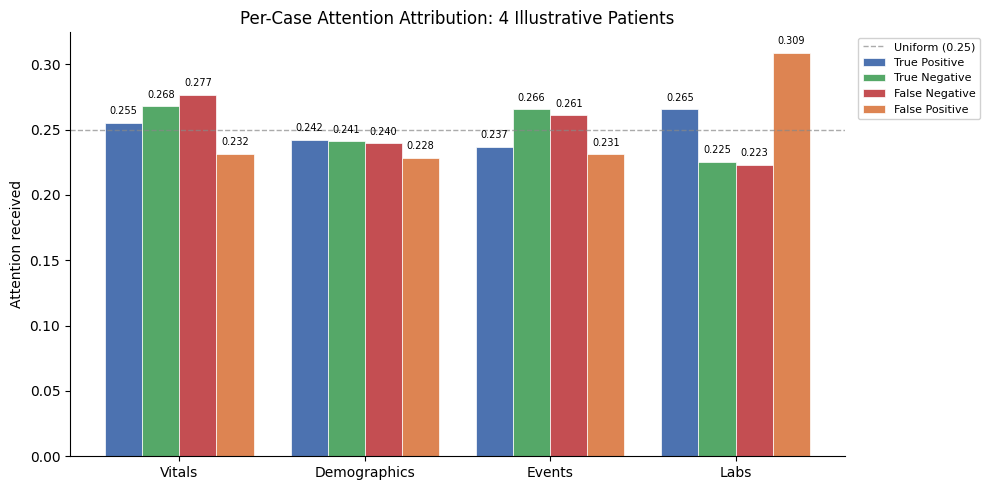

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
modality_labels = ['Vitals', 'Demographics', 'Events', 'Labs']
x = np.arange(len(modality_labels))
width = 0.2
colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

for i, (case_name, idx) in enumerate(cases.items()):
    attn = attn_received_per_patient[idx]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, attn, width, label=case_name, color=colors[i], edgecolor='white', linewidth=0.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=7)

ax.axhline(0.25, color='#888888', linestyle='--', alpha=0.7, linewidth=1, label='Uniform (0.25)')

ax.set_xticks(x)
ax.set_xticklabels(modality_labels)
ax.set_ylabel('Attention received')
ax.set_title('Per-Case Attention Attribution: 4 Illustrative Patients')

ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True, framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('per_case_attention.png', dpi=150, facecolor='white', bbox_inches='tight')
plt.show()

## 12. Performance on Excluded (Sicker) Patients

In [ ]:
import warnings
warnings.filterwarnings('ignore')

excluded_ids = sorted(set(patients_df['icustay_id']) - set(common_ids))
print(f"Evaluating {len(excluded_ids)} excluded patients...")

# Training means 
train_vitals_mean = model_df.loc[train_ids, feature_cols_vitals].mean().values
train_events_mean = model_df_ev.loc[train_ids, feature_cols_ev].mean().values
train_labs_mean = model_df_labs.loc[train_ids, feature_cols_labs].mean().values

probs_late_excluded = []
labels_excluded = []

for sid in excluded_ids:
    hadm = stay_to_hadm.get(sid)
    if hadm is None:
        continue

    # Vitals + Demographics
    if sid in model_df.index:
        vitals_raw = model_df.loc[sid, feature_cols_vitals].values.reshape(1, -1)
    else:
        vitals_raw = train_vitals_mean.reshape(1, -1)
    vitals_imp = imputer.transform(vitals_raw)          # fill NaNs
    vitals_scaled = scaler.transform(vitals_imp)        # standardize
    probs_v = logreg_v.predict_proba(vitals_scaled)[0, 1]

    # Discrete Events
    if sid in model_df_ev.index:
        events_feat = model_df_ev.loc[sid, feature_cols_ev].values.reshape(1, -1)
    else:
        events_feat = train_events_mean.reshape(1, -1)
    probs_e = logreg_e.predict_proba(events_feat)[0, 1]

    # LSTM (Vitals Sequences)
    dummy_seq = np.tile(train_mean, (1, 48, 1))   
    dummy_seq_norm = (dummy_seq - train_mean) / train_std
    with torch.no_grad():
        logits_lstm = model_lstm(torch.tensor(dummy_seq_norm, dtype=torch.float32).to(device),
                                 torch.tensor([48], dtype=torch.long))
        probs_lstm = torch.sigmoid(logits_lstm).cpu().numpy()[0]

    # Labs
    if sid in model_df_labs.index:
        labs_raw = model_df_labs.loc[sid, feature_cols_labs].values.reshape(1, -1)
    else:
        labs_raw = train_labs_mean.reshape(1, -1)
    labs_imp = labs_imputer.transform(labs_raw)
    labs_scaled = labs_scaler.transform(labs_imp)
    probs_l = logreg_labs_fair.predict_proba(labs_scaled)[0, 1]

    # Late Fusion: Average
    prob_avg = np.mean([probs_v, probs_e, probs_lstm, probs_l])
    probs_late_excluded.append(prob_avg)
    labels_excluded.append(labels_lookup[sid])

# Evaluate
auroc_excluded = roc_auc_score(labels_excluded, probs_late_excluded)
auprc_excluded = average_precision_score(labels_excluded, probs_late_excluded)

print(f"\nExcluded Patients (n={len(labels_excluded)}):")
print(f"  AUROC: {auroc_excluded:.4f}")
print(f"  AUPRC: {auprc_excluded:.4f}")
print(f"\nIncluded Test Set (n={len(y_test_true)}):")
print(f"  AUROC: {roc_auc_score(y_test_true, probs_late_fusion):.4f}")
print(f"  AUPRC: {average_precision_score(y_test_true, probs_late_fusion):.4f}")

warnings.filterwarnings('default')

Evaluating 4472 excluded patients...

Excluded Patients (n=4472):
  AUROC: 0.8444
  AUPRC: 0.6071

Included Test Set (n=6409):
  AUROC: 0.9013
  AUPRC: 0.5667


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# MICE imputation on full cohort (36,515 patients) to test MNAR bias
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Merge all features into one DataFrame
full_df = patients_df.merge(agg, on='icustay_id', how='left')
full_df = full_df.merge(events_df, on='hadm_id', how='left')
full_df = full_df.merge(labs_pivot, on='hadm_id', how='left')

# Remove leakage codes (family meetings happen after deterioration, not before)
leakage_codes = ['proc_Family met with Social Worker', 'proc_Family updated by MD']
full_df = full_df.drop(columns=[c for c in leakage_codes if c in full_df.columns])


numeric_cols = full_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_cols = ['admission_type', 'gender']
for col in cat_cols:
    if col in full_df.columns:
        # One‑hot encode
        dummies = pd.get_dummies(full_df[col], prefix=col, drop_first=False)
        full_df = pd.concat([full_df, dummies], axis=1)
        full_df = full_df.drop(columns=[col])

X_full = full_df.select_dtypes(include=['int64', 'float64']).copy()
if 'mortality_label' in X_full.columns:
    y_full = X_full['mortality_label'].values
    X_full = X_full.drop(columns=['mortality_label'])
else:
    y_full = patients_df['mortality_label'].values

drop_cols = ['icustay_id', 'hadm_id', 'subject_id']
X_full = X_full.drop(columns=[c for c in drop_cols if c in X_full.columns], errors='ignore')

X_full = X_full.select_dtypes(include=['int64', 'float64'])

print(f"Full cohort size: {len(X_full)} patients, {X_full.shape[1]} numeric features")

# MICE imputation (or fallback to median if too slow)
try:
    print("Starting MICE imputation (10 iterations)...")
    imputer = IterativeImputer(max_iter=10, random_state=42, verbose=2)
    X_imputed = imputer.fit_transform(X_full)
    print("MICE imputation complete.")
except Exception as e:
    print(f"MICE failed ({e}), falling back to median imputation.")
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X_full)

# Scale
X_scaled = StandardScaler().fit_transform(X_imputed)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_full, test_size=0.2, stratify=y_full, random_state=42)
clf = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
clf.fit(X_train, y_train)
probs = clf.predict_proba(X_test)[:, 1]

# Results
auc = roc_auc_score(y_test, probs)
auprc = average_precision_score(y_test, probs)
late_fusion_auc = roc_auc_score(y_test_true, probs_late_fusion)

print(f"Full cohort (MICE) AUROC: {auc:.4f}, AUPRC: {auprc:.4f}")
print(f"Drop from complete-case Late Fusion ({late_fusion_auc:.4f}): {late_fusion_auc - auc:.4f}")

Full cohort size: 36515 patients, 254 numeric features
Starting MICE imputation (10 iterations)...


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[IterativeImputer] Completing matrix with shape (36515, 254)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[IterativeImputer] Ending imputation round 1/10, elapsed time 431.20
[IterativeImputer] Change: 102.120599253555, scaled tolerance: 3.6950000000000003 


...

/usr/local/lib/python3.13/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


MICE imputation complete.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Full cohort (MICE) AUROC: 0.8795, AUPRC: 0.5562
Drop from complete-case Late Fusion (0.9013): 0.0218


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
mice_auc = auc
mice_auprc = auprc

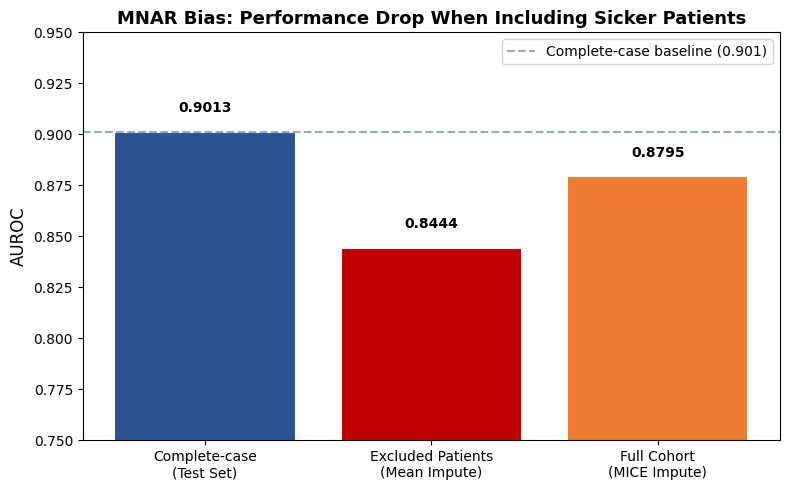

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# MNAR Bias: Complete-case vs Excluded vs Full Imputed
import matplotlib.pyplot as plt

complete_case_auroc = roc_auc_score(y_test_true, probs_late_fusion)

categories = ['Complete-case\n(Test Set)', 'Excluded Patients\n(Mean Impute)', 'Full Cohort\n(MICE Impute)']
aurocs = [complete_case_auroc, auroc_excluded, mice_auc]
colors = ['#2E5395', '#C00000', '#ED7D31']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(categories, aurocs, color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylim(0.75, 0.95)
ax.set_ylabel('AUROC', fontsize=12)
ax.set_title('MNAR Bias: Performance Drop When Including Sicker Patients', fontsize=13, fontweight='bold')
ax.axhline(y=complete_case_auroc, color='#2E5395', linestyle='--', alpha=0.5,
           label=f'Complete-case baseline ({complete_case_auroc:.3f})')
ax.legend()

for bar, val in zip(bars, aurocs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.008, f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('mnar_bias_chart.png', dpi=300)
plt.show()

In [ ]:
# Subgroup analysis: performance by age, gender, admission type

pos_map = {sid: i for i, sid in enumerate(test_ids)}

# Get test patients data
patients_test = patients_df[patients_df['icustay_id'].isin(test_ids)].copy()

# Create age groups
age_bins = [18, 40, 60, 80, 100]
age_labels = ['18-40', '40-60', '60-80', '80+']
patients_test['age_group'] = pd.cut(patients_test['age'], bins=age_bins, labels=age_labels)

results = []

print("Subgroup Analysis on Test Set")

# By age group
print("\n By Age Group")
for group in age_labels:
    mask = patients_test['age_group'] == group
    if mask.sum() > 0:
        idx = patients_test.loc[mask, 'icustay_id'].values
        pos = [pos_map[sid] for sid in idx if sid in pos_map]
        if pos:
            y_group = y_test_true[pos]
            probs_group = np.array(probs_late_fusion)[pos]
            auc = roc_auc_score(y_group, probs_group)
            n = len(pos)
            mortality = y_group.mean()
            results.append({'Subgroup': f'Age {group}', 'n': n, 'AUROC': auc, 'Mortality': mortality})
            print(f"Age {group}: n={n}, AUROC={auc:.4f}, Mortality={mortality:.3f}")

# By gender
print("\n By Gender")
for gender in ['M', 'F']:
    mask = patients_test['gender'] == gender
    if mask.sum() > 0:
        idx = patients_test.loc[mask, 'icustay_id'].values
        pos = [pos_map[sid] for sid in idx if sid in pos_map]
        if pos:
            y_group = y_test_true[pos]
            probs_group = np.array(probs_late_fusion)[pos]
            auc = roc_auc_score(y_group, probs_group)
            n = len(pos)
            mortality = y_group.mean()
            results.append({'Subgroup': f'Gender {gender}', 'n': n, 'AUROC': auc, 'Mortality': mortality})
            print(f"Gender {gender}: n={n}, AUROC={auc:.4f}, Mortality={mortality:.3f}")

# By admission type
for adm in ['EMERGENCY', 'ELECTIVE', 'URGENT']:
    mask = patients_test['admission_type'] == adm
    if mask.sum() > 0:
        idx = patients_test.loc[mask, 'icustay_id'].values
        pos = [pos_map[sid] for sid in idx if sid in pos_map]
        if pos:
            y_group = y_test_true[pos]
            probs_group = np.array(probs_late_fusion)[pos]
            auc = roc_auc_score(y_group, probs_group)
            n = len(pos)
            mortality = y_group.mean()
            results.append({'Subgroup': f'Admission {adm}', 'n': n, 'AUROC': auc, 'Mortality': mortality})
            print(f"Admission {adm}: n={n}, AUROC={auc:.4f}, Mortality={mortality:.3f}")

df_subgroup = pd.DataFrame(results)
print("Summary Table:")
print(df_subgroup.to_string(index=False))

Subgroup Analysis on Test Set

--- By Age Group ---
Age 18-40: n=694, AUROC=0.9646, Mortality=0.053
Age 40-60: n=1923, AUROC=0.9129, Mortality=0.077
Age 60-80: n=2779, AUROC=0.8980, Mortality=0.099
Age 80+: n=992, AUROC=0.8344, Mortality=0.174

--- By Gender ---
Gender M: n=3688, AUROC=0.9091, Mortality=0.092
Gender F: n=2721, AUROC=0.8910, Mortality=0.108
Admission EMERGENCY: n=5247, AUROC=0.8913, Mortality=0.113
Admission ELECTIVE: n=1038, AUROC=0.9307, Mortality=0.024
Admission URGENT: n=124, AUROC=0.9459, Mortality=0.105
Summary Table:
           Subgroup    n    AUROC  Mortality
          Age 18-40  694 0.964581   0.053314
          Age 40-60 1923 0.912892   0.077483
          Age 60-80 2779 0.898007   0.098597
            Age 80+  992 0.834353   0.174395
           Gender M 3688 0.909075   0.091920
           Gender F 2721 0.890953   0.108049
Admission EMERGENCY 5247 0.891315   0.113398
 Admission ELECTIVE 1038 0.930661   0.024085
   Admission URGENT  124 0.945946   0.104839


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


AUROC difference (Included - Excluded): 0.0569 95% CI [0.0388, 0.0751] p=0.0000


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


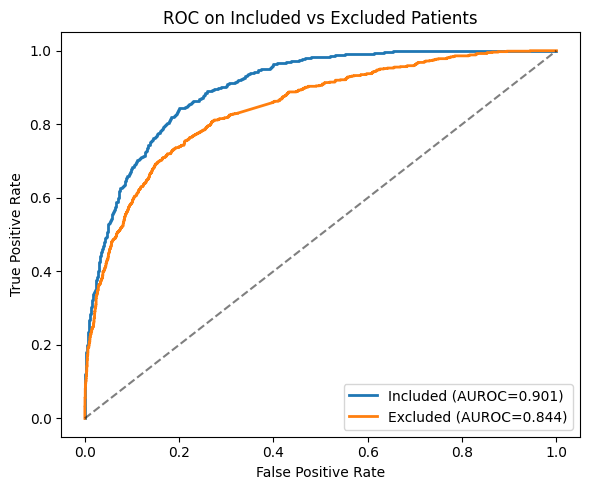

In [ ]:
# Statistical comparison: included test set vs excluded
from sklearn.metrics import roc_auc_score

y_included = y_test_true
probs_included = probs_late_fusion
y_excluded = np.array(labels_excluded)
probs_excluded = np.array(probs_late_excluded)

# Bootstrap difference in AUROC (two‑sample)
n_boot = 1000
diffs = []
for _ in range(n_boot):
    idx_incl = np.random.choice(len(y_included), len(y_included), replace=True)
    idx_excl = np.random.choice(len(y_excluded), len(y_excluded), replace=True)
    auc_incl = roc_auc_score(y_included[idx_incl], probs_included[idx_incl])
    auc_excl = roc_auc_score(y_excluded[idx_excl], probs_excluded[idx_excl])
    diffs.append(auc_incl - auc_excl)

diffs = np.array(diffs)
mean_diff = np.mean(diffs)
ci_lower, ci_upper = np.percentile(diffs, [2.5, 97.5])
p_val = 2 * min(np.mean(diffs > 0), np.mean(diffs < 0))

print(f"AUROC difference (Included - Excluded): {mean_diff:.4f} 95% CI [{ci_lower:.4f}, {ci_upper:.4f}] p={p_val:.4f}")

# ROC curves 

fpr_incl, tpr_incl, _ = roc_curve(y_included, probs_included)
fpr_excl, tpr_excl, _ = roc_curve(y_excluded, probs_excluded)

plt.figure(figsize=(6,5))
plt.plot(fpr_incl, tpr_incl, label=f'Included (AUROC={roc_auc_score(y_included, probs_included):.3f})', linewidth=2)
plt.plot(fpr_excl, tpr_excl, label=f'Excluded (AUROC={roc_auc_score(y_excluded, probs_excluded):.3f})', linewidth=2)
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC on Included vs Excluded Patients')
plt.legend()
plt.tight_layout()
plt.show()

### Decision Curve Analysis

Late Fusion crosses zero net benefit at threshold ≈ 0.101
Cross-Attention crosses zero net benefit at threshold ≈ 0.359


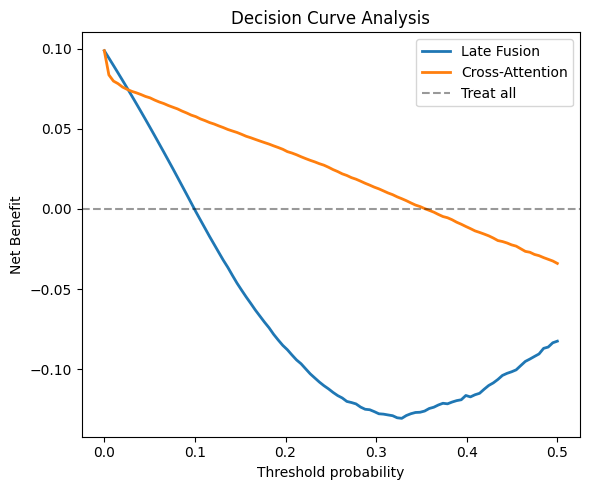

In [ ]:
def net_benefit(y_true, y_probs, thresholds):
    nb = []
    for thresh in thresholds:
        tp = ((y_probs > thresh) & (y_true == 1)).sum()
        fp = ((y_probs > thresh) & (y_true == 0)).sum()
        n = len(y_true)
        nb.append((tp/n) - (fp/n) * (thresh/(1-thresh)))
    return np.array(nb)

thresholds = np.linspace(0, 0.5, 100)

nb_late = net_benefit(y_test_true, probs_late_fusion, thresholds)
nb_cross = net_benefit(y_test_true, probs_attn_te, thresholds)

crossover_late = thresholds[np.where(nb_late <= 0)[0][0]]
crossover_cross = thresholds[np.where(nb_cross <= 0)[0][0]]
print(f"Late Fusion crosses zero net benefit at threshold ≈ {crossover_late:.3f}")
print(f"Cross-Attention crosses zero net benefit at threshold ≈ {crossover_cross:.3f}")

plt.figure(figsize=(6, 5))
plt.plot(thresholds, nb_late, label='Late Fusion', linewidth=2)
plt.plot(thresholds, nb_cross, label='Cross-Attention', linewidth=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.4, label='Treat all')
plt.xlabel('Threshold probability')
plt.ylabel('Net Benefit')
plt.title('Decision Curve Analysis')
plt.legend()
plt.tight_layout()
plt.savefig('decision_curve.png', dpi=150)
plt.show()

Loaded severity scores for 36515 patients
Merged severity scores.

Severity columns in patients_df: ['sofa_score', 'sapsii', 'qsofa_score', 'apsiii_score']

Non‑null counts in test set:
sofa_score: 6409 out of 6409 patients
sapsii: 6409 out of 6409 patients
qsofa_score: 6409 out of 6409 patients
apsiii_score: 6409 out of 6409 patients

Traditional Severity Scores vs Late Fusion Model

Late Fusion (our model): AUROC=0.9013, AUPRC=0.5667

SOFA: AUROC=0.7532, AUPRC=0.3285, n=6409
SAPSII: AUROC=0.8174, AUPRC=0.3859, n=6409


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: date

QSOFA: AUROC=0.5904, AUPRC=0.1231, n=6409
APSIII: AUROC=0.8053, AUPRC=0.3854, n=6409

Summary Table:
 Score    AUROC    AUPRC    n
  SOFA 0.753195 0.328541 6409
SAPSII 0.817429 0.385906 6409
 QSOFA 0.590415 0.123119 6409
APSIII 0.805348 0.385363 6409


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


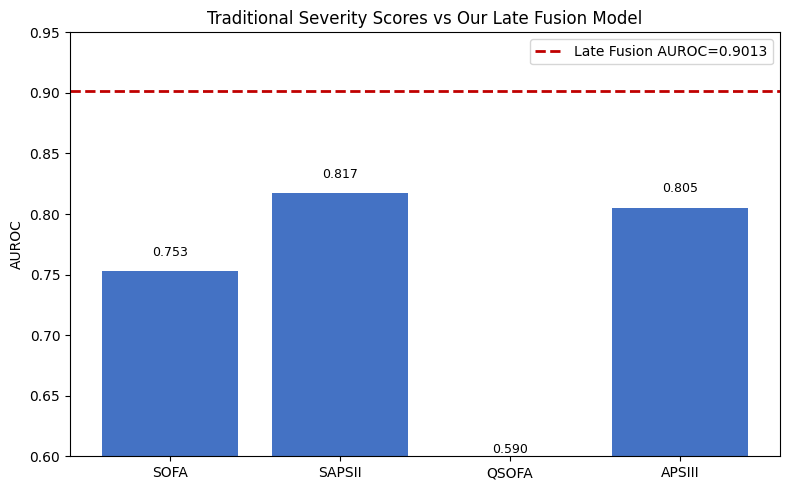

Plot saved to /content/drive/MyDrive/mimic_project/severity_scores_comparison.png


In [ ]:
# Load severity scores and compare with late fusion
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

save_dir = '/content/drive/MyDrive/mimic_project'

# Load severity scores
severity_scores = pd.read_csv(f'{save_dir}/severity_scores.csv')
print(f"Loaded severity scores for {len(severity_scores)} patients")

cols_to_drop = [c for c in patients_df.columns if 'sofa' in c.lower() or 'sapsii' in c.lower() or 'qsofa' in c.lower() or 'apsiii' in c.lower()]
if cols_to_drop:
    patients_df = patients_df.drop(columns=cols_to_drop, errors='ignore')
    print(f"Dropped existing severity columns: {cols_to_drop}")

# Merge scores
patients_df = patients_df.merge(severity_scores, on='icustay_id', how='left')
print("Merged severity scores.")

patients_df = patients_df.set_index('icustay_id')

severity_cols = ['sofa_score', 'sapsii', 'qsofa_score', 'apsiii_score']
print("\nSeverity columns in patients_df:", [c for c in patients_df.columns if c in severity_cols])

# Check non-null counts in test set (using loc with index)
print("\nNon‑null counts in test set:")
for col in severity_cols:
    if col in patients_df.columns:
        test_available = patients_df.loc[test_ids, col].notna().sum()
        print(f"{col}: {test_available} out of {len(test_ids)} patients")
    else:
        print(f"{col} not found")

# Compare with Late Fusion
results = []
late_auc = roc_auc_score(y_test_true, probs_late_fusion)
late_auprc = average_precision_score(y_test_true, probs_late_fusion)

print("Traditional Severity Scores vs Late Fusion Model")
print(f"\nLate Fusion (our model): AUROC={late_auc:.4f}, AUPRC={late_auprc:.4f}\n")

for col in severity_cols:
    if col in patients_df.columns:
        X = patients_df.loc[test_ids, [col]].values
        y = y_test_true
        mask = ~np.isnan(X).flatten()
        X_clean = X[mask].reshape(-1, 1)
        y_clean = y[mask]
        if len(X_clean) > 50 and len(np.unique(y_clean)) > 1:
            lr = LogisticRegression().fit(X_clean, y_clean)
            probs = lr.predict_proba(X_clean)[:, 1]
            auc = roc_auc_score(y_clean, probs)
            auprc = average_precision_score(y_clean, probs)
            results.append({
                'Score': col.replace('_score', '').upper(),
                'AUROC': auc,
                'AUPRC': auprc,
                'n': len(X_clean)
            })
            print(f"{col.replace('_score', '').upper()}: AUROC={auc:.4f}, AUPRC={auprc:.4f}, n={len(X_clean)}")
        else:
            print(f"{col}: insufficient data (n={len(X_clean)})")

# Summary table
df_scores = pd.DataFrame(results)
print("Summary Table:")
if not df_scores.empty:
    print(df_scores.to_string(index=False))
else:
    print("No results – check column names.")

# Plot
if not df_scores.empty:
    plt.figure(figsize=(8,5))
    bars = plt.bar(df_scores['Score'], df_scores['AUROC'], color='#4472C4')
    plt.axhline(y=late_auc, color='#C00000', linestyle='--', linewidth=2,
                label=f'Late Fusion AUROC={late_auc:.4f}')
    plt.ylabel('AUROC')
    plt.title('Traditional Severity Scores vs Our Late Fusion Model')
    plt.legend()
    for bar, val in zip(bars, df_scores['AUROC']):
        plt.text(bar.get_x() + bar.get_width()/2., val + 0.01, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=9)
    plt.ylim(0.6, 0.95)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/severity_scores_comparison.png', dpi=150)
    plt.show()
    print(f"Plot saved to {save_dir}/severity_scores_comparison.png")
else:
    print("No results to plot.")

In [ ]:
# Compute Late Fusion Train AUROC to check overfitting

# Vitals+Demo LogReg
X_train_v = model_df.loc[train_ids_fit, feature_cols_vitals]
X_train_v_imp = imputer.transform(X_train_v)
X_train_v_s = scaler.transform(X_train_v_imp)
probs_v_train = logreg_v.predict_proba(X_train_v_s)[:, 1]

# Discrete Events LogReg
X_train_e = model_df_ev.loc[train_ids_fit, feature_cols_ev]
probs_e_train = logreg_e.predict_proba(X_train_e)[:, 1]

# LSTM (Vitals Sequences)
model_lstm.eval()
with torch.no_grad():
    logits_lstm_train = model_lstm(
        torch.tensor(X_train_seq, dtype=torch.float32).to(device),
        torch.tensor(len_train_seq, dtype=torch.long)
    )
    probs_lstm_train = torch.sigmoid(logits_lstm_train).cpu().numpy().flatten()

# Labs LogReg
X_train_labs = model_df_labs.loc[train_ids_fit, feature_cols_labs]
X_train_labs_imp = labs_imputer.transform(X_train_labs)
X_train_labs_s = labs_scaler.transform(X_train_labs_imp)
probs_labs_train = logreg_labs_fair.predict_proba(X_train_labs_s)[:, 1]

probs_late_fusion_train = np.mean([probs_v_train, probs_e_train, probs_lstm_train, probs_labs_train], axis=0)

y_train_true = patients_df.loc[train_ids_fit, 'mortality_label'].values

# Compute AUROC
train_auc = roc_auc_score(y_train_true, probs_late_fusion_train)
test_auc = roc_auc_score(y_test_true, probs_late_fusion)

print("Late Fusion Overfitting Check")
print(f"Train AUROC: {train_auc:.4f}")
print(f"Test AUROC:  {test_auc:.4f}")
print(f"Gap:         {train_auc - test_auc:.4f}")
if train_auc - test_auc > 0.05:
    print("Some overfitting detected (gap > 0.05)")
else:
    print("No significant overfitting (gap <= 0.05)")